# Clustering with [Python](https://www.python.org/) &nbsp;<a href="https://www.python.org/"><img src="https://s3.dualstack.us-east-2.amazonaws.com/pythondotorg-assets/media/community/logos/python-logo-only.png" style="max-width: 35px; display: inline" alt="Python"/></a>


_Large multi-spectral image segmentation: Representing the geological diversity of the surface of Mars_

---

The objective of this tutorial is to use in practice the different concepts studied during the course on clustering. Image segmentation is a standard problem where unsupervised classification is used. Here, we want to apply clustering to the pixels of a multi-spectral image representing the surface of Mars. The goal is to identify different "types" of pixels corresponding to different geological compositions, thus generating a geological map of Mars.

---

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 10

--- 

## Objective and Data exploration

**Data**: The data in the `mars.csv` file represent a hyper-spectral image of the surface of Mars. Visible and near-infrared imagery is a key tele-detection technique, used to study planets thanks to satellites with on-board spectrometers. In march 2014, the OMEGA equipment collected more than 310 Go of raw images. It mapped Mars surface with a resolution between 300 and 3000 meters, depending on the height of the space ship ([Bibring et al., 2005](https://pubmed.ncbi.nlm.nih.gov/15718430/)). For each pixel, the spectral response between 0.36 and 5.2 μm was collected and sampled accross 255 channels. The objective is to characterize the geological composition of Mars surface and in particular to distinguish between different classes of silicates, minerals, oxydes, carbonates and frozen regions.

These data are represented by an image of 300 x 128 pixels.

In [2]:
mars = pd.read_csv("data/mars.csv.zip")

mars.describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255
count,38400.000000,38400.000000,38400.000000,38400.000000,38400.000000,38400.000000,38400.000000,38400.000000,38400.000000,38400.000000,...,38400.000000,38400.000000,38400.000000,38400.000000,38400.000000,38400.000000,38400.000000,38400.000000,38400.000000,38400.000000
mean,0.373672,0.408012,0.418404,0.420980,0.421814,0.421358,0.426807,0.429181,0.419277,0.418314,...,0.327834,0.358084,0.366237,0.341929,0.376129,0.394448,0.373834,0.370925,0.409842,0.413357
std,0.098974,0.080131,0.080369,0.081863,0.081315,0.080683,0.080681,0.081414,0.078250,0.077991,...,0.064647,0.056778,0.050779,0.059134,0.052337,0.056993,0.064088,0.062586,0.056333,0.053984
min,0.038469,0.233688,0.259045,0.269580,0.273937,0.274090,0.275866,0.274769,0.273685,0.274631,...,0.143893,0.193508,0.219910,0.174218,0.220138,0.215826,0.198084,0.186781,0.224686,0.219101
25%,0.299668,0.334763,0.343065,0.345050,0.344962,0.345116,0.350838,0.352490,0.346149,0.345396,...,0.272904,0.312169,0.330923,0.295109,0.339747,0.352853,0.324080,0.321077,0.369166,0.375433
50%,0.365481,0.388543,0.397193,0.399102,0.399245,0.398413,0.403601,0.407299,0.396357,0.394954,...,0.334283,0.362259,0.367263,0.344043,0.375732,0.397163,0.378828,0.372294,0.411261,0.414135
75%,0.445685,0.487916,0.502658,0.507322,0.508697,0.508175,0.512995,0.515465,0.503711,0.502607,...,0.379558,0.400942,0.398504,0.385884,0.409758,0.433080,0.420058,0.419563,0.447426,0.448774
max,0.832065,0.590190,0.580816,0.579686,0.580050,0.579551,0.584240,0.591300,0.569333,0.567649,...,0.559236,0.596519,2.304593,1.393481,0.661885,0.651398,0.624899,0.652349,0.699387,0.655508


##### <span style="color:purple">**Question:** How many spectral values are observed for each pixel?</span>

--> 255

We can start by checking that the images are indeed composed of 300 x 128 pixels.

<!-- 255 spectral values -->

In [3]:
# %load solutions/data/nb_pixels.py
mars_data = mars.to_numpy()

# Dimensions de l'image
n_pixel_x = 300
n_pixel_y = 128

n_pixel = mars.shape[0]
dim_spectral = mars.shape[1]

print("Image size: n_x.n_y:", n_pixel_x*n_pixel_y)
print("Number of pixels   :", n_pixel)
print("Number of channels :", dim_spectral)

Image size: n_x.n_y: 38400
Number of pixels   : 38400
Number of channels : 255


##### <span style="color:purple">**Todo:** Represent the spectral response as a map on the image of Mars.</span>

To answer this question :
* Randomly select 6 wavelengths,
* Visualize the spectral response as an image. You can use the `imshow` function for this purpose.

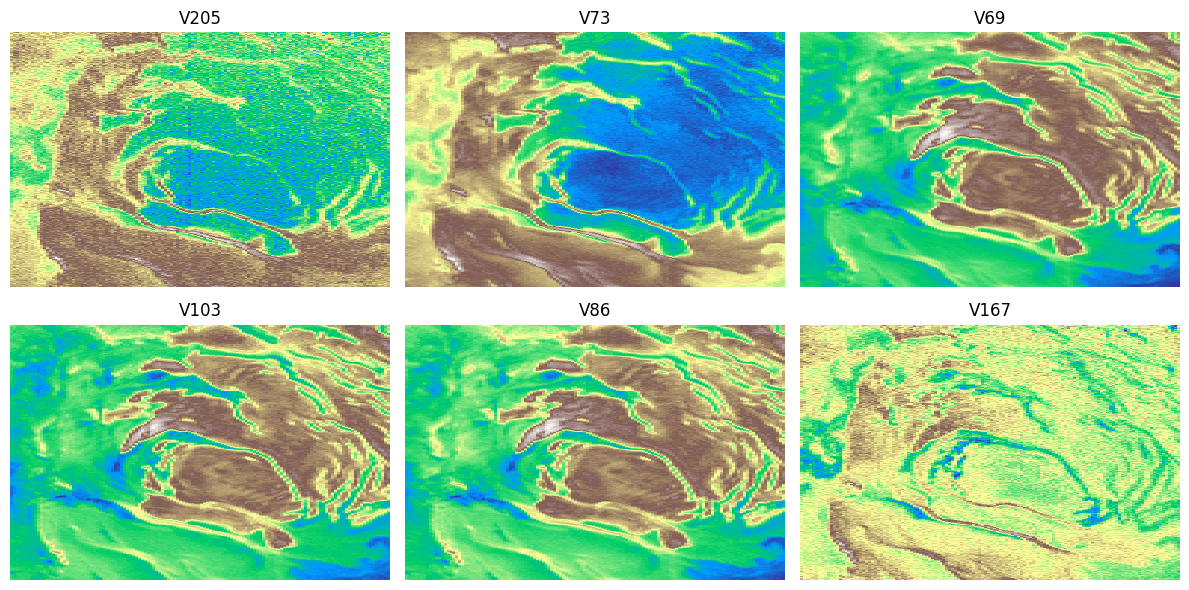

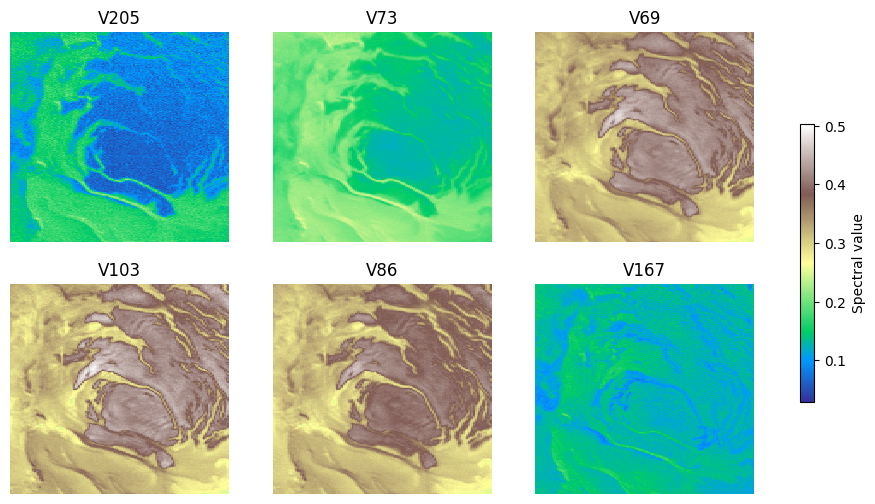

In [4]:
# %load solutions/data/spectral_response.py

plotIndex = np.random.randint(0, 255, 6)

# --- #
# Free colorbar

fig, axes = plt.subplots(2, 3, figsize=(12, 6))

for ax, idx in zip(axes.flat, plotIndex):
    mars_image = mars_data[:, idx].reshape(n_pixel_x, n_pixel_y)
    ax.imshow(mars_image, interpolation="nearest", aspect="auto", cmap="terrain")
    ax.set_title(f"V{idx+1}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# --- #
# Shared colorbar

vmin = mars_data[:,plotIndex].min()
vmax = mars_data[:,plotIndex].max()
fig, axes = plt.subplots(2, 3, figsize=(12, 6))

for ax, idx in zip(axes.flat, plotIndex):
    mars_image = mars_data[:, idx].reshape(n_pixel_x, n_pixel_y)
    im = ax.imshow(mars_image, interpolation="nearest", aspect="auto",
                   cmap="terrain", vmin=vmin, vmax=vmax)
    ax.set_title(f"V{idx+1}")
    ax.axis("off")

fig.colorbar(im, ax=axes, shrink=0.6, label="Spectral value")
plt.show()

### Exploration of the wave length distributions

##### <span style="color:purple">**Question:** How are the spectral values distributed?</span>

To answer this question :
* For the same 6 variables as those selected previously, plot the histrogram of the distribution of these spectral values.
* We can focus on the symmetry, dispersion and possible multimodal nature of the variables. 

In [5]:
### TO BE COMPLETED ### 

[...]

[Ellipsis]

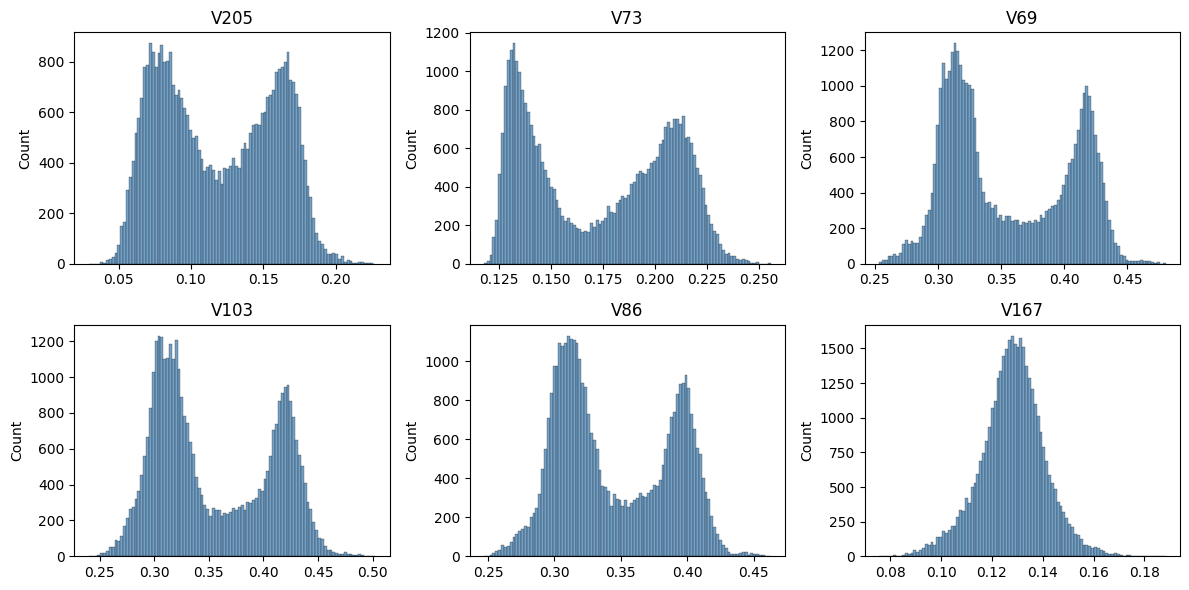

In [6]:
# %load solutions/data/spectral_distrib.py
fig, axes = plt.subplots(2, 3, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    sns.histplot(mars_data[:, plotIndex[i]], bins=100, ax=ax, color="steelblue")
    ax.set_title(f"V{plotIndex[i]+1}")
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

##### <span style="color:purple">**Question:** Does standardizing this data make sense?</span>

To answer this question:
* Represent the boxplots of all wave lengths.
* Compare the range of the data, their median, the presence of outliers.

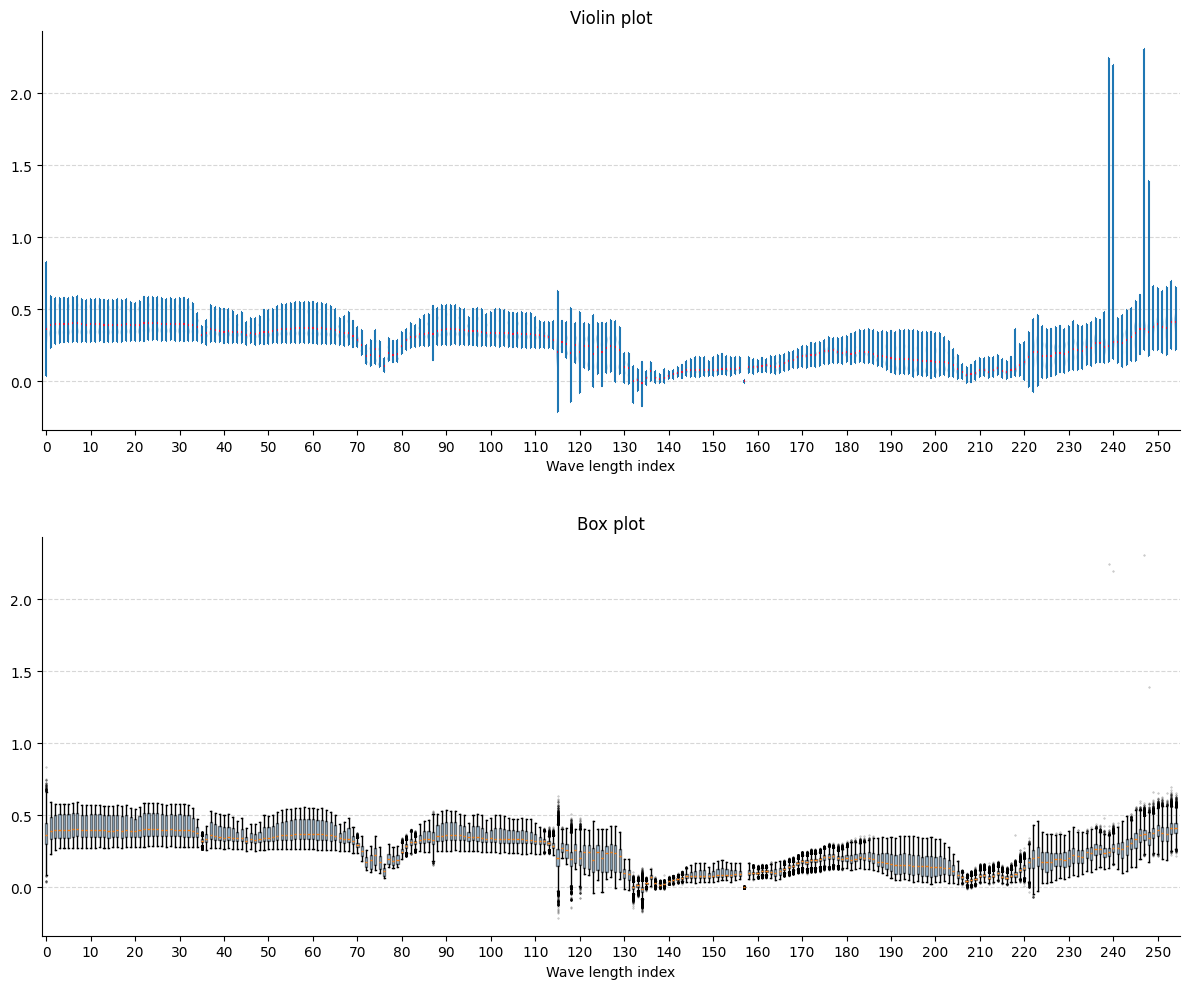

In [7]:
# %load solutions/data/data_bp.py
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Violin plot
vp = axes[0].violinplot(mars_data, showmeans=False, showmedians=True,
                         positions=range(dim_spectral))
for body in vp["bodies"]:
    body.set_alpha(0.6)
vp["cmedians"].set_color("crimson")
axes[0].set_title("Violin plot")

# Box plot
bp = axes[1].boxplot(mars_data, positions=range(dim_spectral),
                     patch_artist=True, flierprops=dict(marker=".", markersize=1, alpha=0.3))
for patch in bp["boxes"]:
    patch.set(facecolor="steelblue", alpha=0.5)
axes[1].set_title("Box plot")

# Shared formatting
ticks = range(0, dim_spectral, 10)
for ax in axes:
    ax.yaxis.grid(True, linestyle="--", alpha=0.5)
    ax.set_xlim(-1, dim_spectral)
    ax.set_xticks(ticks)
    ax.set_xticklabels(ticks)
    ax.set_xlabel("Wave length index")
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout(h_pad=3)
plt.show()

##### <span style="color:purple">**Todo:** Plot the spectra of a subsample of pixels.</span>

In [8]:
### TO BE COMPLETED ### 

[...]

[Ellipsis]

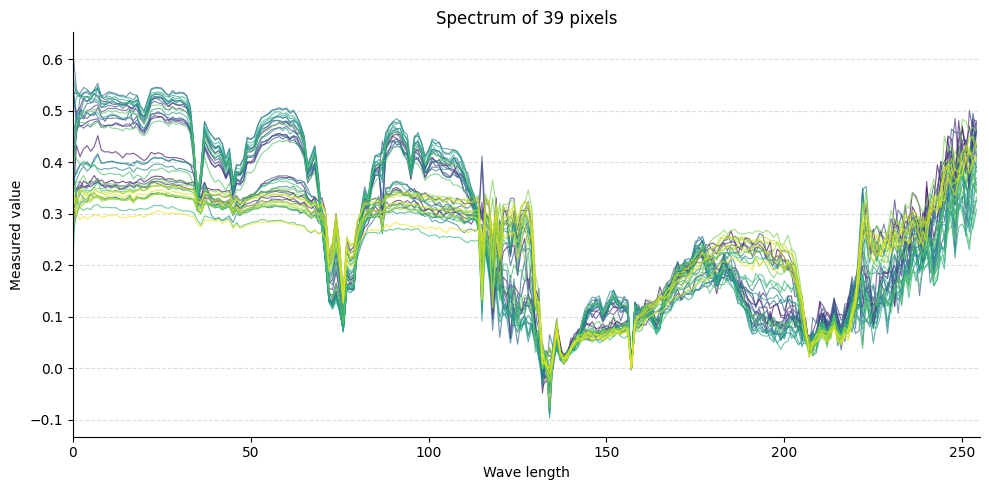

In [9]:
# %load solutions/data/spectra.py
sample = mars_data[::1000]
x = np.arange(dim_spectral)

fig, ax = plt.subplots(figsize=(10, 5))

palette = sns.color_palette("viridis", sample.shape[0])
for i, (spectrum, color) in enumerate(zip(sample, palette)):
    ax.plot(x, spectrum, color=color, alpha=0.7, linewidth=0.8)

ax.set_title(f"Spectrum of {sample.shape[0]} pixels")
ax.set_xlabel("Wave length")
ax.set_ylabel("Measured value")
ax.set_xlim(0, dim_spectral)
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

### Data standardization

In [10]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
mars_scaled = ss.fit_transform(mars_data)

##### <span style="color:purple">**Todo:** Verify the effect of standardization.</span>

1. For the same 6 variables as those selected previously, draw the histrograms of their standardized counterparts, and compare with the raw observations.
2. Represent the boxplots of all wave lengths.

Visualization of different wave length distributions after standard scaling 



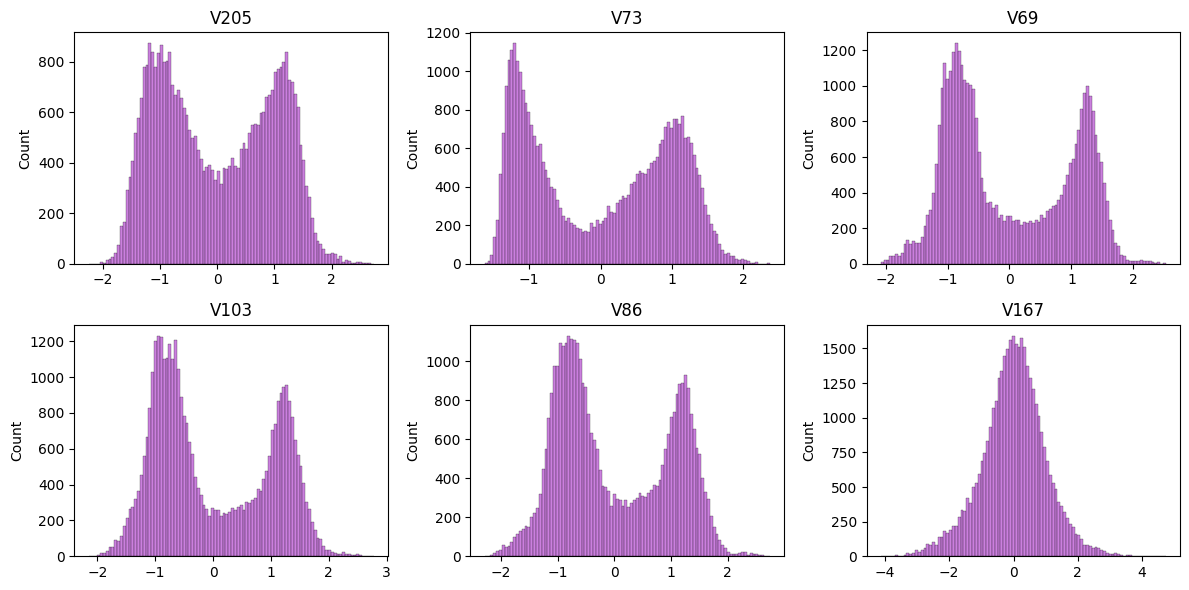

In [11]:
# %load solutions/data/scaled_spectral_distrib.py
print("Visualization of different wave length distributions after standard scaling \n")
fig, axes = plt.subplots(2, 3, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    sns.histplot(mars_scaled[:, plotIndex[i]], bins=100, ax=ax, color="mediumorchid")
    ax.set_title(f"V{plotIndex[i]+1}")
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

Comparison of the wave length distributions, before and after standard scaling 



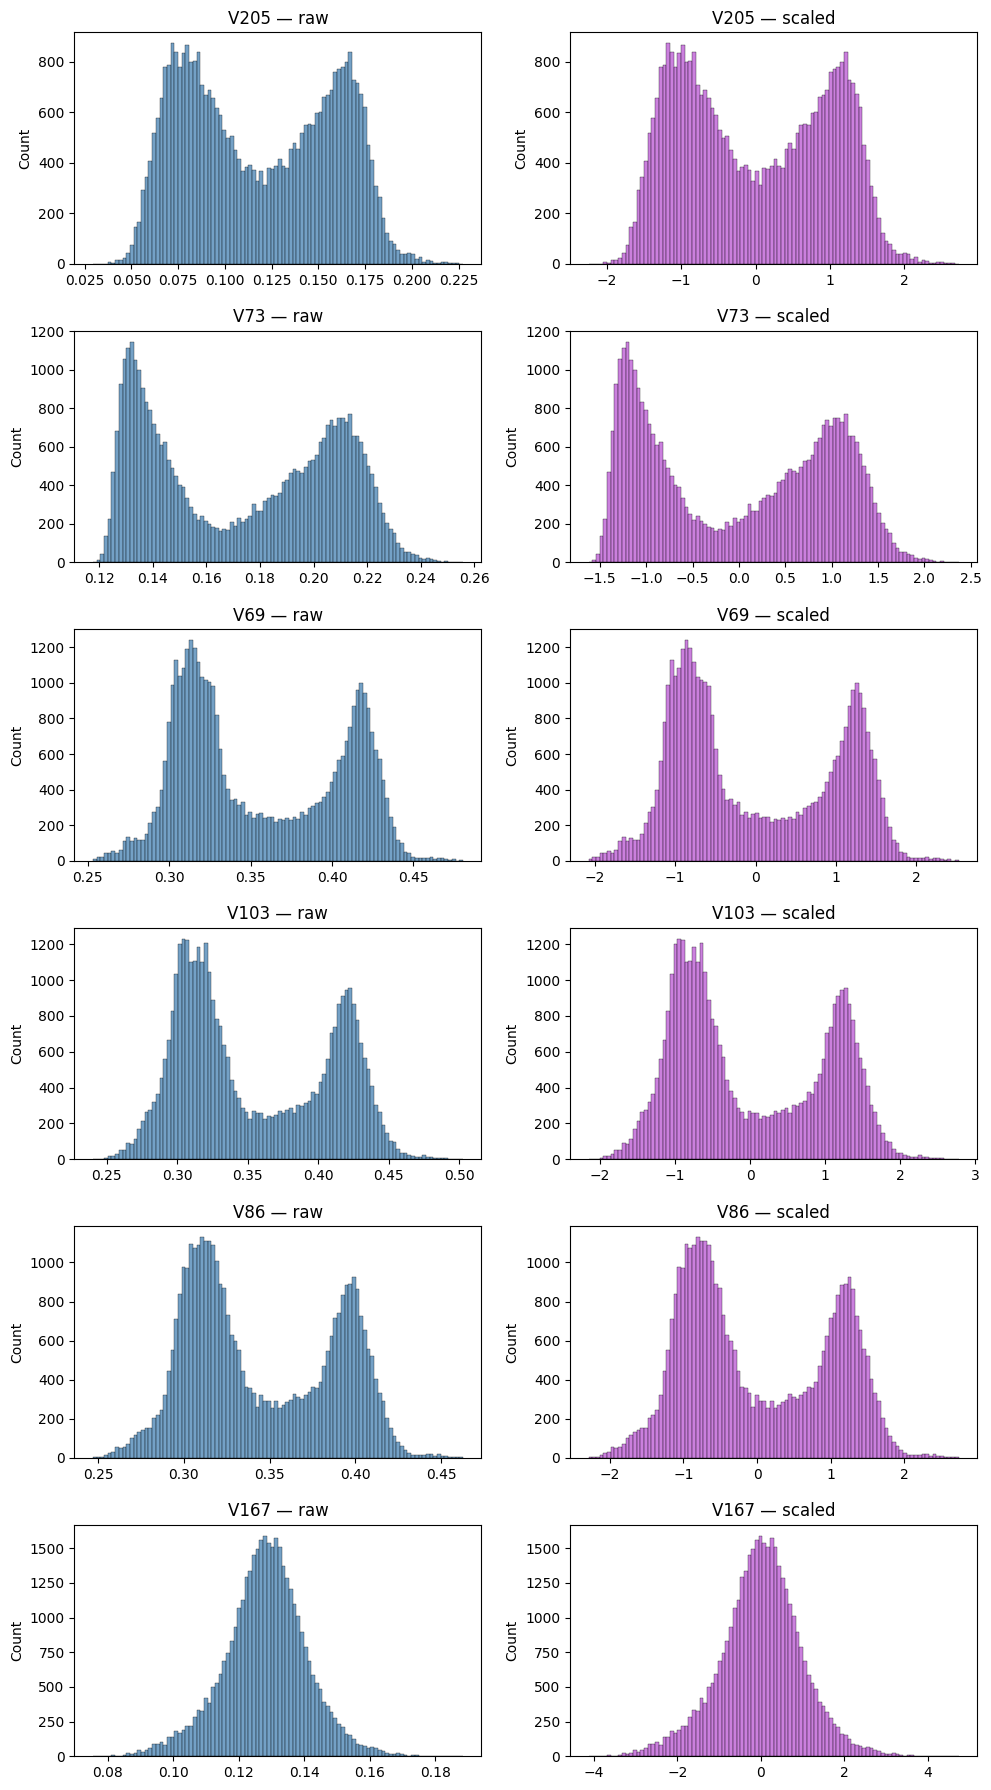

In [12]:
# %load solutions/data/compare_spectral_distrib.py
print("Comparison of the wave length distributions, before and after standard scaling \n")
fig, axes = plt.subplots(6, 2, figsize=(10, 18))

for i, (ax_raw, ax_scaled) in enumerate(axes):
    idx = plotIndex[i]
    
    sns.histplot(mars_data[:, idx], bins=100, ax=ax_raw, color="steelblue")
    ax_raw.set_title(f"V{idx+1} — raw")
    ax_raw.set_xlabel("")

    sns.histplot(mars_scaled[:, idx], bins=100, ax=ax_scaled, color="mediumorchid")
    ax_scaled.set_title(f"V{idx+1} — scaled")
    ax_scaled.set_xlabel("")

plt.tight_layout(h_pad=1.5)
plt.show()

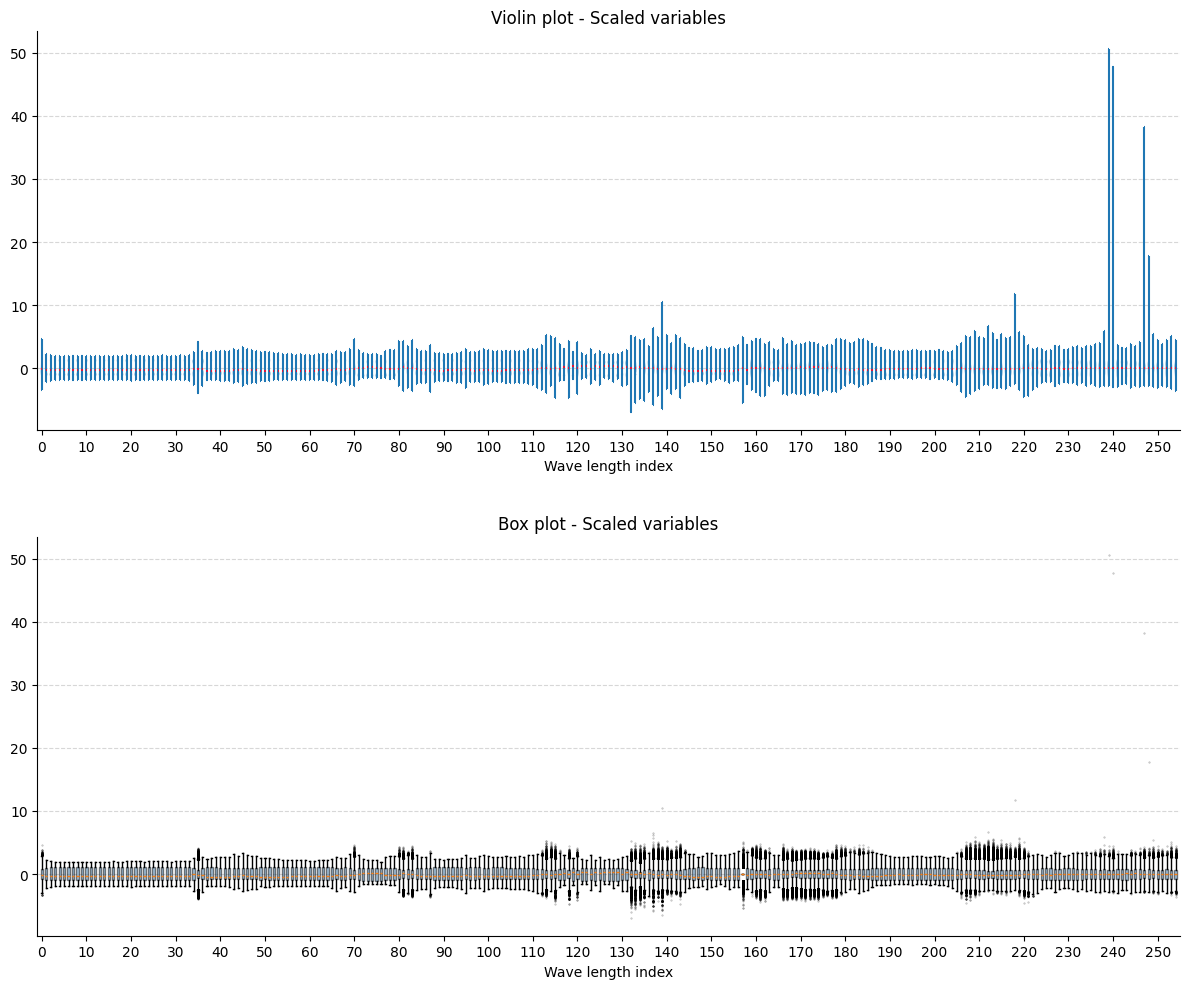

In [13]:
# %load solutions/data/scaled_bp.py
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Violin plot
vp = axes[0].violinplot(mars_scaled, showmeans=False, showmedians=True,
                         positions=range(dim_spectral))
for body in vp["bodies"]:
    body.set_alpha(0.6)
vp["cmedians"].set_color("crimson")
axes[0].set_title('Violin plot - Scaled variables')

# Box plot
bp = axes[1].boxplot(mars_scaled, positions=range(dim_spectral),
                     patch_artist=True, flierprops=dict(marker=".", markersize=1, alpha=0.3))
for patch in bp["boxes"]:
    patch.set(facecolor="steelblue", alpha=0.5)
axes[1].set_title('Box plot - Scaled variables')

# Shared formatting
ticks = range(0, dim_spectral, 10)
for ax in axes:
    ax.yaxis.grid(True, linestyle="--", alpha=0.5)
    ax.set_xlim(-1, dim_spectral)
    ax.set_xticks(ticks)
    ax.set_xticklabels(ticks)
    ax.set_xlabel("Wave length index")
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout(h_pad=3)
plt.show()

### Dimension reduction by Principal Component Analysis (PCA)

In [14]:
from sklearn.decomposition import PCA

pca = PCA()
mars_pca = pca.fit_transform(mars_scaled)

##### <span style="color:purple">**Question:** How many components on the PCA should we keep?</span>

In [15]:
### TO BE COMPLETED ##

[...]

[Ellipsis]

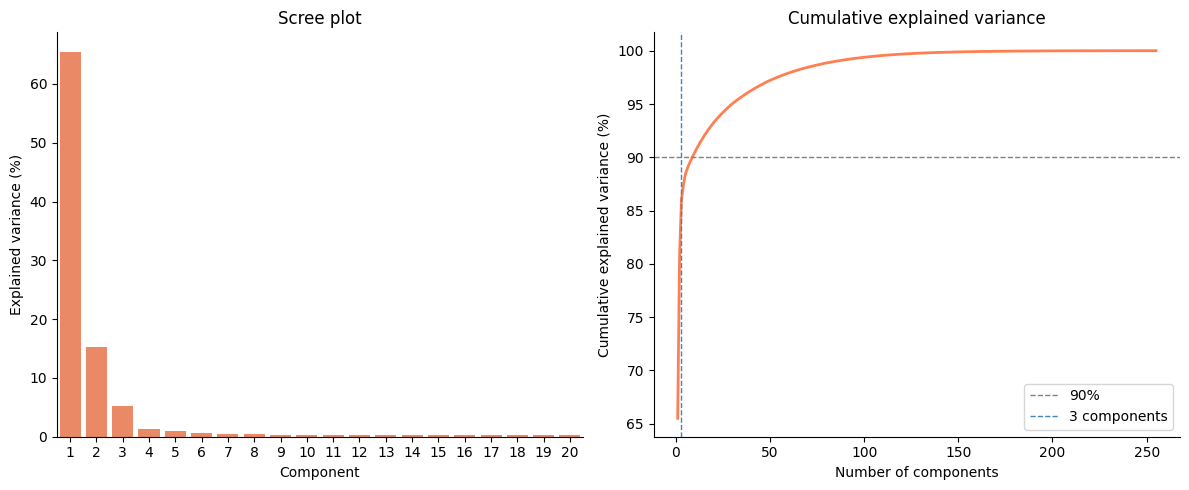

Variance explained by the first 3 components: 86.01%


In [16]:
# %load solutions/pca/pca_components.py
explained_variance_ratio = 100 * pca.explained_variance_ratio_
n_bars = 20

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scree plot
sns.barplot(x=np.arange(1, n_bars + 1), y=explained_variance_ratio[:n_bars],
            color="coral", ax=axes[0])
axes[0].set_xlabel("Component")
axes[0].set_ylabel("Explained variance (%)")
axes[0].set_title("Scree plot")
axes[0].spines[["top", "right"]].set_visible(False)

# Cumulative explained variance
cumvar = np.cumsum(explained_variance_ratio)
axes[1].plot(np.arange(1, len(cumvar) + 1), cumvar, color="coral", linewidth=2)
axes[1].axhline(90, color="gray", linestyle="--", linewidth=1, label="90%")
axes[1].axvline(3, color="steelblue", linestyle="--", linewidth=1, label="3 components")
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative explained variance (%)")
axes[1].set_title("Cumulative explained variance")
axes[1].legend()
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Variance explained by the first 3 components: {cumvar[2]:.2f}%")

##### <span style="color:purple">**Todo:** Visualize the dispersion of the observations on the 10-th first components of the PCA.</span>

<span style="color:gray">[Indication]</span> 
<!-- Display the boxplot of the 10-th first components of the PCA. -->

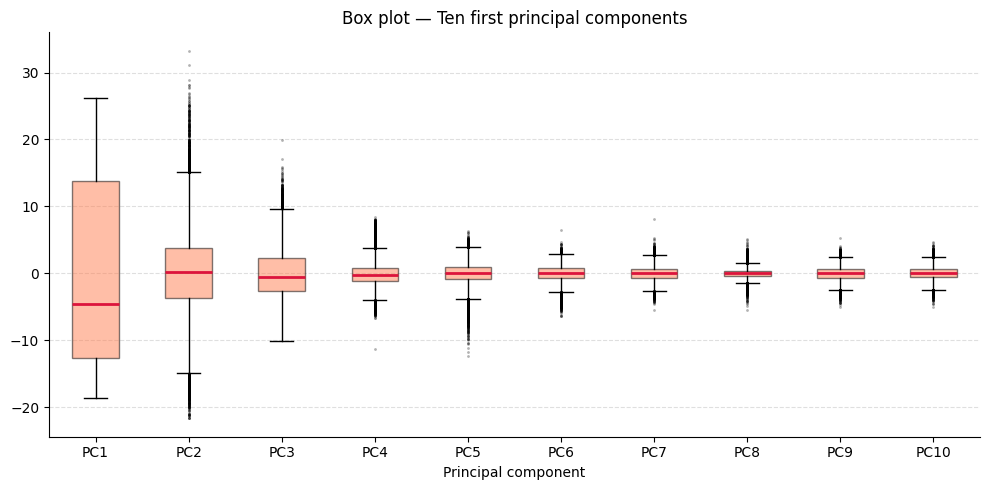

In [17]:
# %load solutions/pca/pca_bp.py
fig, ax = plt.subplots(figsize=(10, 5))

bp = ax.boxplot(mars_pca[:, :10], patch_artist=True,
                medianprops=dict(color="crimson", linewidth=2),
                flierprops=dict(marker=".", markersize=2, alpha=0.3),
                boxprops=dict(facecolor="coral", alpha=0.5))

ax.set_title("Box plot — Ten first principal components")
ax.set_xlabel("Principal component")
ax.set_xticklabels([f"PC{i+1}" for i in range(10)])
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

#### Variable factor map


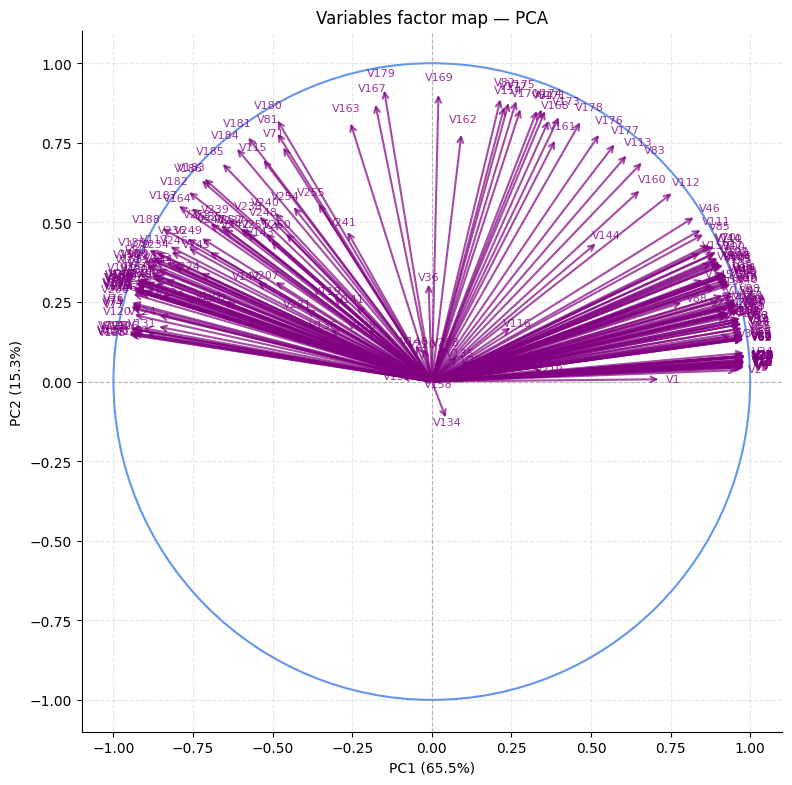

In [18]:
coord1 = pca.components_[0] * np.sqrt(pca.explained_variance_[0])
coord2 = pca.components_[1] * np.sqrt(pca.explained_variance_[1])

fig, ax = plt.subplots(figsize=(8, 8))

# Arrows and labels
for x, y, name in zip(coord1, coord2, mars.columns):
    ax.annotate("", xy=(x, y), xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color="purple", alpha=0.7, lw=1.5))
    ax.text(x * 1.05, y * 1.05, name, fontsize=8,
            ha="center", va="center", color="purple", alpha=0.8)

# Unit circle
circle = plt.Circle((0, 0), radius=1, color="cornflowerblue", fill=False, linewidth=1.5)
ax.add_patch(circle)

# Formatting
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
ax.axvline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_aspect("equal")
ax.set_title("Variables factor map — PCA")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

##### <span style="color:purple">**Todo:** Comment the above figure.</span>

#### Individual factor maps

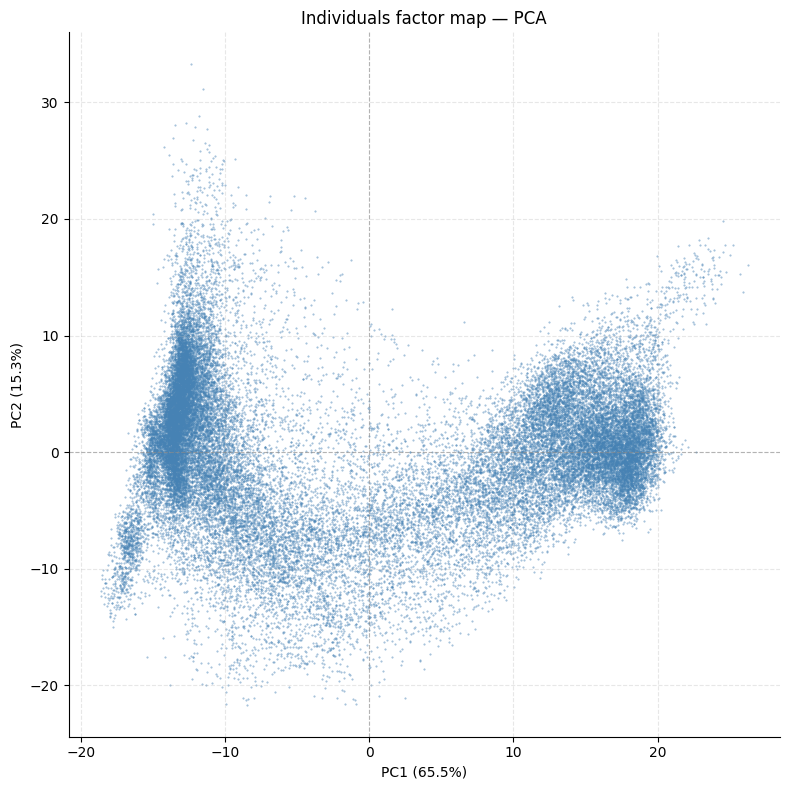

In [19]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(mars_pca[:, 0], mars_pca[:, 1], s=0.2, alpha=0.6, color="steelblue")

ax.set_title("Individuals factor map — PCA")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
ax.axvline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

##### <span style="color:purple">**Question:** Does a six-class clustering - as suggested by the experts - seem appropriate to you?</span>

#### Biplot

The following function is used to obtain the biplot associated with the PCA.

In [20]:
def biplot(scores, coords, labels=None, feature_labels=None):
    """
    Biplot combining individual factor map and variable factor map.

    Parameters
    ----------
    scores        : projected data coordinates, shape (n_samples, 2)
    coords        : feature coordinates (loadings), shape (n_features, 2)
    labels        : point color array (cluster labels or continuous values), optional
    feature_labels: feature names to display on arrows, optional
    """
    xs = scores[:, 0]
    ys = scores[:, 1]
    scalex = 1.0 / (xs.max() - xs.min())
    scaley = 1.0 / (ys.max() - ys.min())

    fig, ax = plt.subplots(figsize=(10, 8), dpi=100)

    # Scatter plot
    scatter_kwargs = dict(s=1, alpha=0.3)
    if labels is not None:
        scatter_kwargs.update(c=labels, cmap="viridis")

    sc = ax.scatter(xs * scalex, ys * scaley, **scatter_kwargs)
    if labels is not None and len(np.unique(labels)) > 6:
        fig.colorbar(sc, ax=ax, shrink=0.6)

    # Arrows and labels
    for i, (cx, cy) in enumerate(coords):
        ax.annotate("", xy=(cx, cy), xytext=(0, 0),
                    arrowprops=dict(arrowstyle="->", color="black", lw=2))
        name = feature_labels[i] if feature_labels is not None else f"Var {i+1}"
        ax.text(cx * 1.15, cy * 1.15, name,
                color="seagreen", ha="center", va="center", fontsize=9)

    # Formatting
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.axvline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_aspect("equal")
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(True, linestyle="--", alpha=0.3)

    plt.tight_layout()

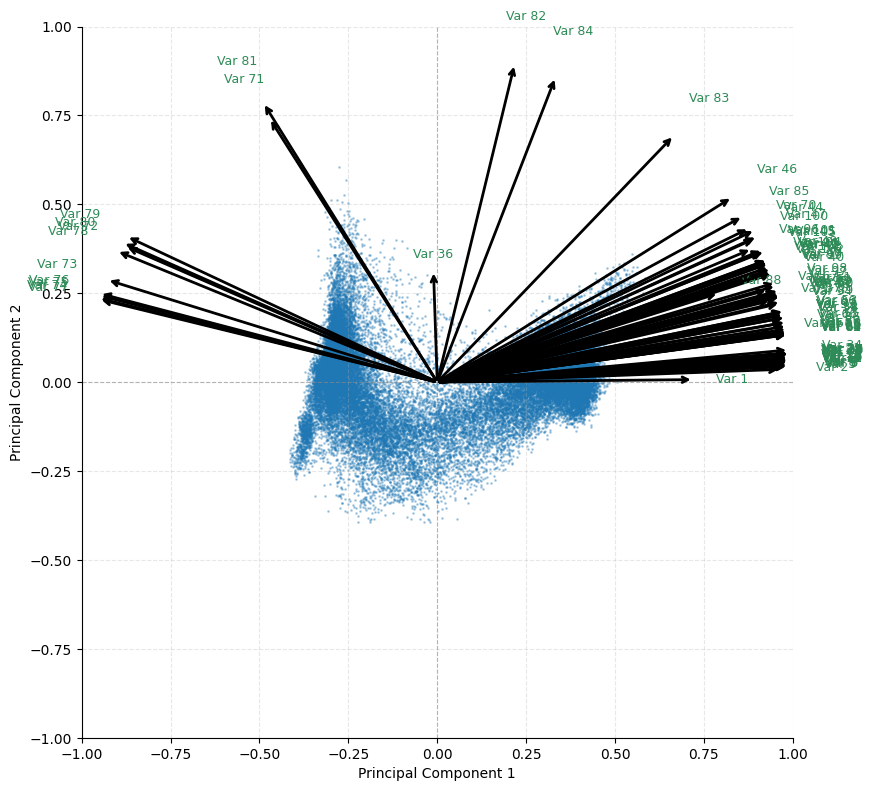

In [21]:
loadings = pca.components_[:2].transpose()
coords = loadings*np.sqrt(pca.explained_variance_[:2])

biplot(mars_pca[:,:2],coords[:105])
plt.show()

For the end of the tutorial, we will restrict ourselves to the first 3 principal components. 

In [22]:
mars_reduced = mars_pca[:,:3]

## Unsupervised classifications and Image segmentation

The goal of this section is to perform a clustering on the spectral data in order to segment the image: each class found will correspond to a geographical area in the image. In particular, we will color the image according to the classification found from now on.

In [23]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from matplotlib import colors

from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

### Classification by dynamic reallocation: $k$-means

We will compare two strategies: the classification of pixels characterized by the first three components of the PCA, then by the full spectrum.

#### $k$-means on PCA reduced data

**Caution**: The reduction of dimension operated by PCA induces properties that may or may not be interesting. In the present case, restricting oneself to the first three components acts as a denoising or low pass filter because the eigenfunctions associated with the small eigenvalues are particularly noisy. This can be useful in this case but can be detrimental in other circumstances; in particular when class or group separations are to be sought in directions associated with small variances. The choice of the distance between objects, here curves, is in any case fundamental.

The graphs linked to PCA suggest keeping three components, which we will do. It is possible to keep more.

##### <span style="color:purple">**Todo:** Perform a classification by the k-means algorithm while setting the number of classes to 6, as suggested in the literature.</span>

- You may use the [`KMeans`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) _scikit-learn_ class;
- Draw a histogram of the obtained classification to see if the classes are globally balanced, or not, with this segmentation. 

In [24]:
### TO BE COMPLETED ##

[...]

[Ellipsis]

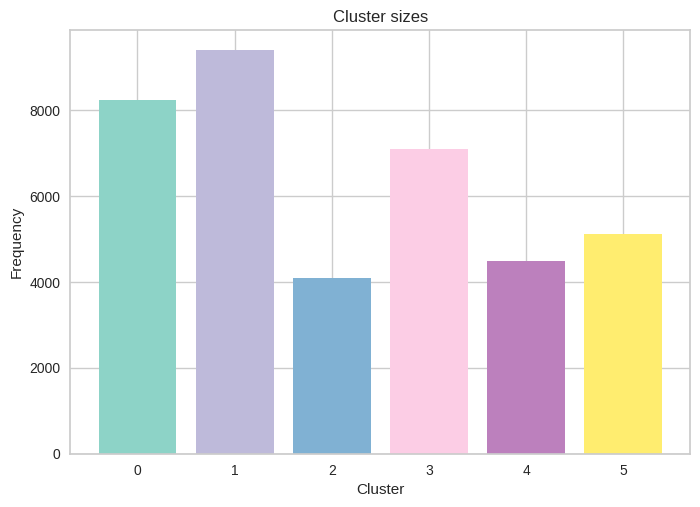

In [25]:
# %load solutions/kmeans/kmeans_hist.py
K = 6

kmeans_pca = KMeans(n_clusters=K, init='k-means++', n_init='auto', random_state=0)
clusters_pca = kmeans_pca.fit_predict(mars_reduced)

# ----- #

cmap = plt.get_cmap('Set3',K)
plt.bar(*np.unique(clusters_pca, return_counts=True), color=cmap.colors)
plt.ylabel("Frequency")
plt.xlabel("Cluster")
plt.title("Cluster sizes")
plt.show()

##### <span style="color:purple">**Todo:** Display the results on individual factor map.</span>

Display the individual factor map with the points colored according to their membership in the class found by $k$-means.

In [26]:
### TO BE COMPLETED ##

[...]

[Ellipsis]

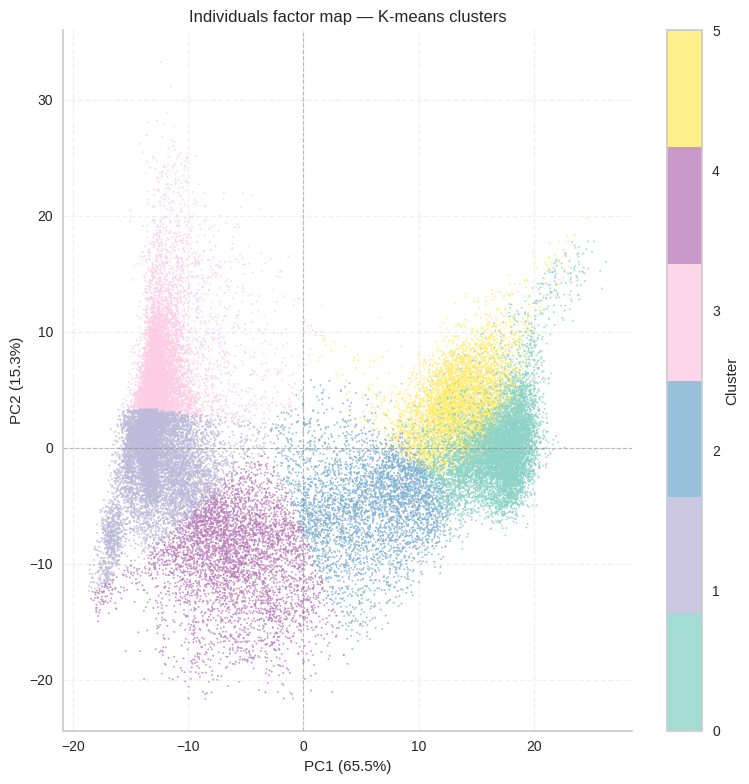

In [27]:
# %load solutions/kmeans/kmeans_acp.py
fig, ax = plt.subplots(figsize=(8, 8))

sc = ax.scatter(mars_pca[:, 0], mars_pca[:, 1],
                c=clusters_pca, s=1, alpha=0.8, cmap=cmap)

ax.set_title("Individuals factor map — K-means clusters")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
ax.axvline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, linestyle="--", alpha=0.3)

fig.colorbar(sc, ax=ax, ticks=range(K), label="Cluster")

plt.tight_layout()
plt.show()

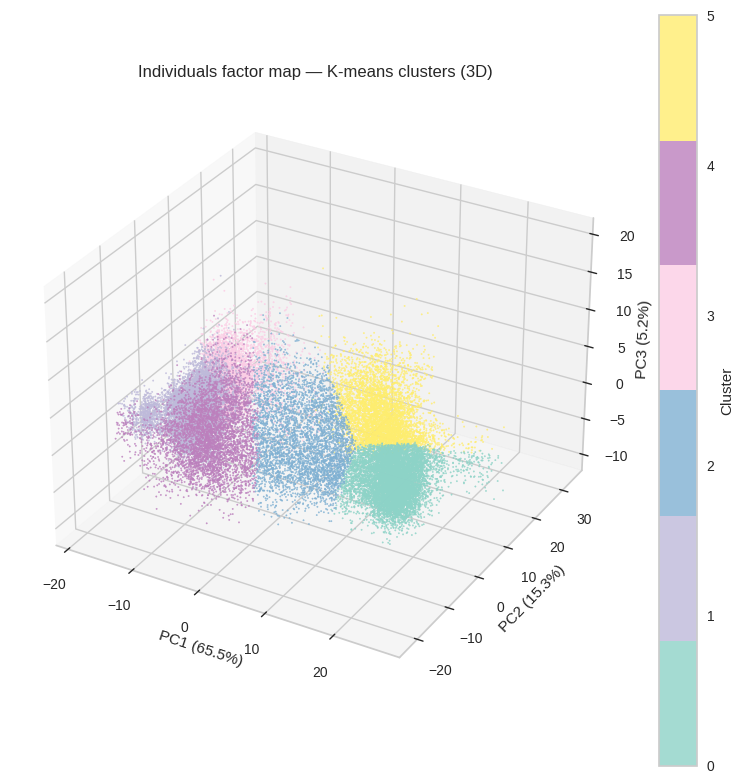

In [28]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(mars_pca[:, 0], mars_pca[:, 1], mars_pca[:, 2],
                c=clusters_pca, s=1, alpha=0.8, cmap=cmap)

ax.set_title("Individuals factor map — K-means clusters (3D)")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_zlabel(f"PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)")

fig.colorbar(sc, ax=ax, ticks=range(K), label="Cluster")

plt.tight_layout()
plt.show()

##### <span style="color:purple">**Todo:** Display the image of MARS geological composition found by clustering.</span>

Represent the Mars image, with the pixels colored according to their membership to the classes found by $k$-means.

In [29]:
### TO BE COMPLETED ##

[...]

[Ellipsis]

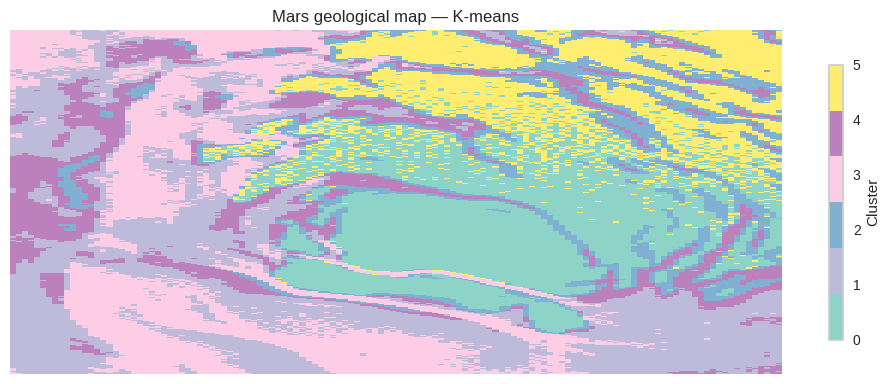

In [30]:
# %load solutions/kmeans/kmeans_img.py
n_pixel_x = 300
n_pixel_y = 128

fig, ax = plt.subplots(figsize=(10, 4))

mars_image = clusters_pca.reshape((n_pixel_x, n_pixel_y))
im = ax.imshow(mars_image, interpolation="nearest", aspect="auto", cmap=cmap)

fig.colorbar(im, ax=ax, ticks=range(K), label="Cluster", shrink=0.8)
ax.set_title("Mars geological map — K-means")
ax.axis("off")

plt.tight_layout()
plt.show()

##### <span style="color:purple">**Todo:** Display the curve representing the wave lengths of the centroids</span>

For each centroid of the classification, plot its mean spectral value.

In [31]:
### TO BE COMPLETED ##

[...]

[Ellipsis]

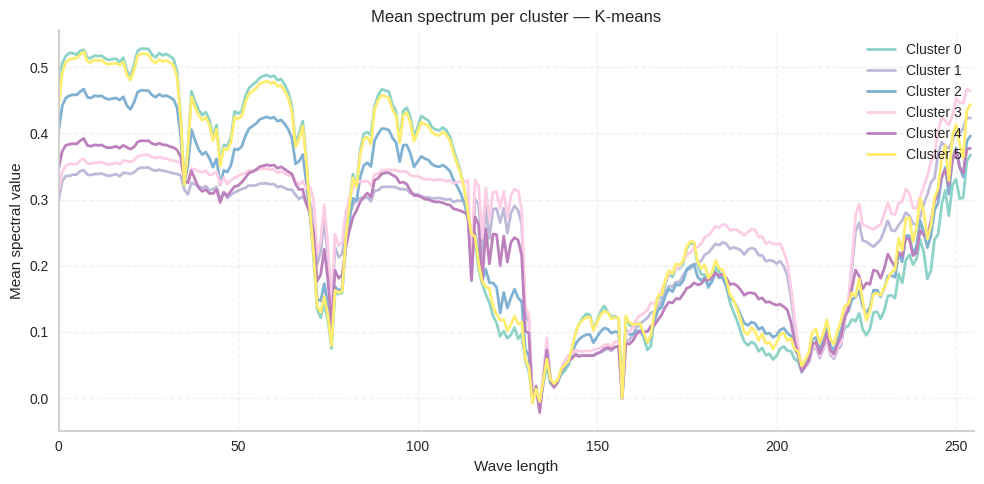

In [32]:
# %load solutions/kmeans/kmeans_centroids.py
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(dim_spectral)
for i in range(K):
    mean_spectrum = np.mean(mars_data[clusters_pca == i], axis=0)
    ax.plot(x, mean_spectrum, color=cmap.colors[i], linewidth=2, label=f"Cluster {i}")

ax.set_xlabel("Wave length")
ax.set_ylabel("Mean spectral value")
ax.set_title("Mean spectrum per cluster — K-means")
ax.set_xlim(0, dim_spectral)
ax.legend(loc="upper right")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

#### Selection of the number of clusters

For the moment, based on theoretical knowledge, we have imposed a cluster number of 6. We will now try to find the otpimal number of clusters, without any prior knowledge.

##### <span style="color:purple">**Todo:** Determine the number of clusters using the elbow method.</span>

In [33]:
### TO BE COMPLETED ##

[...]

[Ellipsis]

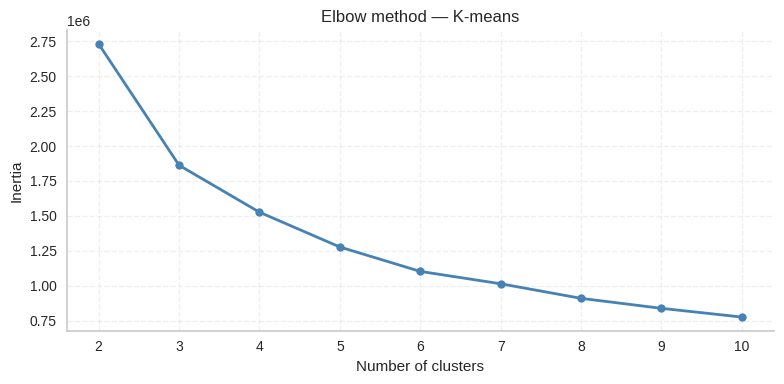

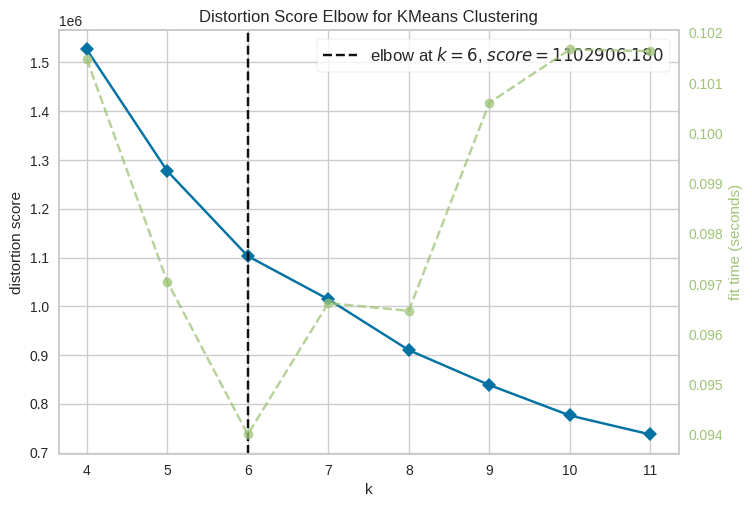

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [34]:
# %load solutions/kmeans/kmeans_elbow.py
# By hand

inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init="auto",
                    max_iter=100, random_state=42)
    inertia.append(kmeans.fit(mars_reduced).inertia_)

inertia = np.array(inertia)

# --- #

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(range(2, 11), inertia[1:], marker="o", color="steelblue",
        linewidth=2, markersize=6)

ax.set_xlabel("Number of clusters")
ax.set_ylabel("Inertia")
ax.set_title("Elbow method — K-means")
ax.set_xticks(range(2, 11))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


# --- #


# Using yellowbrick

kmeans = KMeans(init='k-means++', n_init='auto', max_iter=100, random_state=42)
visualizer = KElbowVisualizer(kmeans, k=(4,12), force_model=True)

visualizer.fit(mars_reduced)    # Fit the data to the visualizer
visualizer.show()    # Finalize and render the figure

##### <span style="color:purple">**Todo:** Determine the number of clusters using the silhouette scores.</span>

In [35]:
### TO BE COMPLETED ### 

[...]

[Ellipsis]

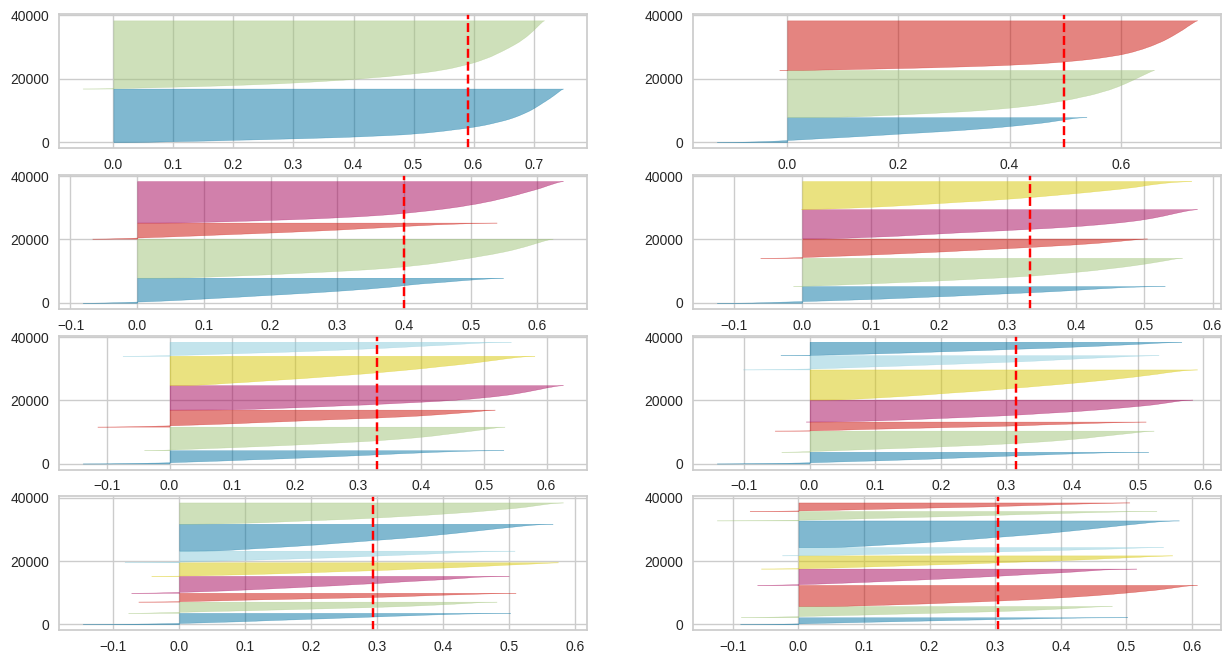

In [36]:
# %load solutions/kmeans/kmeans_silhouette.py
fig, ax = plt.subplots(4, 2, figsize=(15,8))

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init='auto', max_iter=100, random_state=42)
    q, mod = divmod(k, 2)
    
    # Create SilhouetteVisualizer instance with KMeans instance
    visualizer = SilhouetteVisualizer(kmeans, colors='yellowbrick', ax=ax[q-1][mod], force_model=True)
    visualizer.fit(mars_reduced)

##### <span style="color:purple">**Todo:** Represent the geological composition of Mars for 2 classes.</span>

In [37]:
### TO BE COMPLETED ### 
# K = 2

[...]

[Ellipsis]

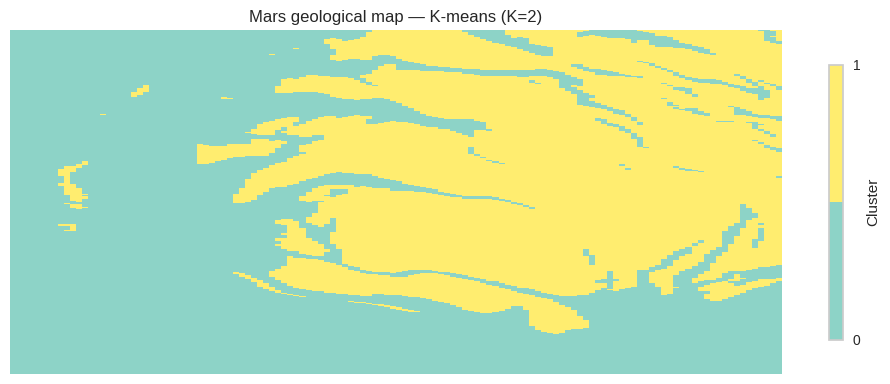

In [38]:
# %load solutions/kmeans/kmeans_2classes.py
K = 2

kmeans_pca = KMeans(n_clusters=K, init="k-means++", n_init="auto")
clusters_pca = kmeans_pca.fit_predict(mars_reduced)

cmap = plt.get_cmap("Set3", K)
fig, ax = plt.subplots(figsize=(10, 4))

im = ax.imshow(clusters_pca.reshape((n_pixel_x, n_pixel_y)),
               interpolation="nearest", aspect="auto", cmap=cmap)

fig.colorbar(im, ax=ax, ticks=range(K), label="Cluster", shrink=0.8)
ax.set_title("Mars geological map — K-means (K=2)")
ax.axis("off")

plt.tight_layout()
plt.show()

#### $k$-means on the complete data 

We choose 6 clusters to match the literature. 

##### <span style="color:purple">**Todo:** Represent the geological composition of Mars for six classes, using the complete data.</span>

In [39]:
### TO BE COMPLETED ### 

[...]

[Ellipsis]

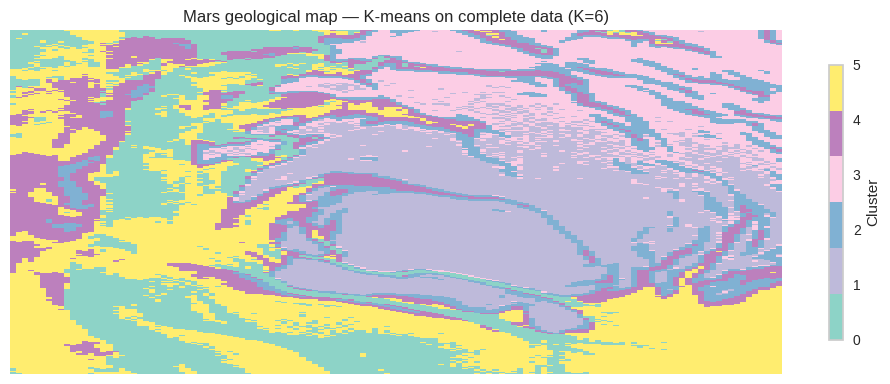

In [40]:
# %load solutions/kmeans/kmeans_complete.py
K = 6

kmeans_full = KMeans(n_clusters=K, init="k-means++", n_init="auto")
clusters_full = kmeans_full.fit_predict(mars_data)

cmap = plt.get_cmap("Set3", K)
fig, ax = plt.subplots(figsize=(10, 4))

im = ax.imshow(clusters_full.reshape((n_pixel_x, n_pixel_y)),
               interpolation="nearest", aspect="auto", cmap=cmap)

fig.colorbar(im, ax=ax, ticks=range(K), label="Cluster", shrink=0.8)
ax.set_title("Mars geological map — K-means on complete data (K=6)")
ax.axis("off")

plt.tight_layout()
plt.show()

### Comparison of the results

##### <span style="color:purple">**Todo:** Visualize side by side the geological image of Mars obtained on the reduced data and on the complete data.</span>

Comment on it.

In [41]:
### TO BE COMPLETED ### 

[...]

[Ellipsis]

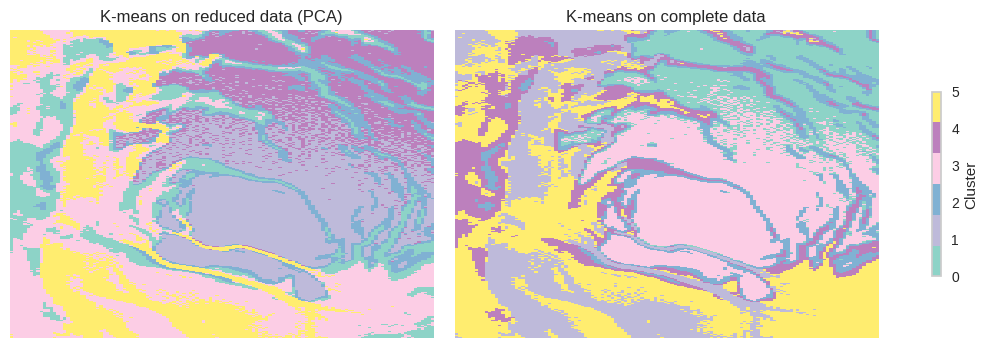

In [42]:
# %load solutions/kmeans/kmeans_compare.py
K = 6
cmap = plt.get_cmap("Set3", K)

kmeans_pca = KMeans(n_clusters=K, init="k-means++", n_init="auto")
clusters_pca = kmeans_pca.fit_predict(mars_reduced)

kmeans_full = KMeans(n_clusters=K, init="k-means++", n_init="auto")
clusters_full = kmeans_full.fit_predict(mars_data)

# --- #

fig, axes = plt.subplots(1, 2, figsize=(14, 4),
                         gridspec_kw={"wspace": 0.05})

titles = ["K-means on reduced data (PCA)", "K-means on complete data"]
images = [clusters_pca, clusters_full]

for ax, img, title in zip(axes, images, titles):
    im = ax.imshow(img.reshape((n_pixel_x, n_pixel_y)),
                   interpolation="nearest", aspect="auto", cmap=cmap)
    ax.set_title(title)
    ax.axis("off")

fig.colorbar(im, ax=axes, ticks=range(K), label="Cluster", shrink=0.6)

plt.show()

In [43]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

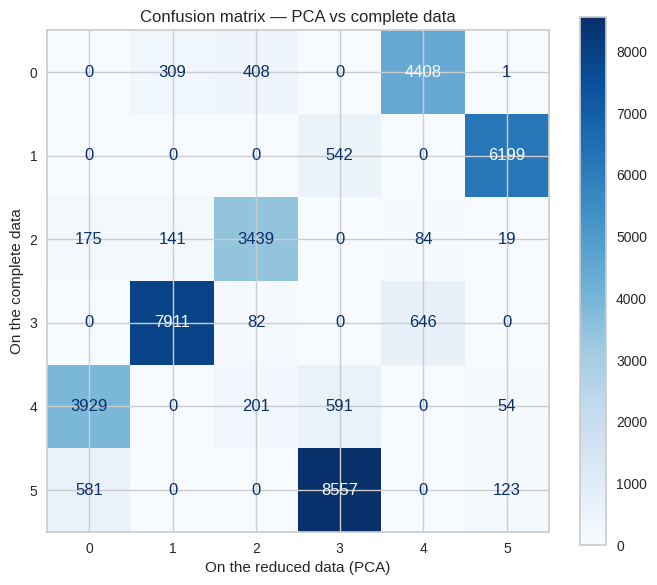

In [44]:
fig, ax = plt.subplots(figsize=(7, 6))

ConfusionMatrixDisplay(confusion_matrix(clusters_full, clusters_pca)).plot(
    ax=ax, colorbar=True, cmap="Blues"
)

ax.set_xlabel("On the reduced data (PCA)")
ax.set_ylabel("On the complete data")
ax.set_title("Confusion matrix — PCA vs complete data")

plt.tight_layout()
plt.show()

##### <span style="color:purple">**Todo:** Write a function `matchClasses`that reorders the classes found in the two classifications so that they match.</span>

You may start from the confusion matrix of the two classifications and try to place its maximal elements on its diagonal. This function should return the rearranged confusion matrix and the associated class indices for each point of the dataset.

In [45]:
### TO BE COMPLETED ### 

def matchClasses(classif1, classif2):
    [...]

In [46]:
# %load solutions/kmeans/matchClasses.py
def matchClasses(classif1, classif2):
    cm = confusion_matrix(classif1, classif2)
    K = cm.shape[0]
    a, b = np.zeros(K), np.zeros(K)
    for j in range(K):
        for i in range(K):
            if (a[j] < cm[i,j]):
                a[j] = cm[i,j]
                b[j] = i 
    a = a.astype(int)
    b = b.astype(int)
                                             
    print ("")
    print ("Classes size:", a)
    print ("Class (in the classif1 numbering):", b)
    print ("")
    
    table = cm.copy()
    for i in range(K):
        table[:,b[i]] = cm[:,i]   
        
    clusters = classif2.copy()
    n = classif2.shape[0]
    for i in range(n):
        for j in range(K):
            if (classif2[i] == j):
                clusters[i] = b[j]
        
    return table, clusters


Classes size: [3929 7911 3439 8557 4408 6199]
Class (in the classif1 numbering): [4 3 2 5 0 1]



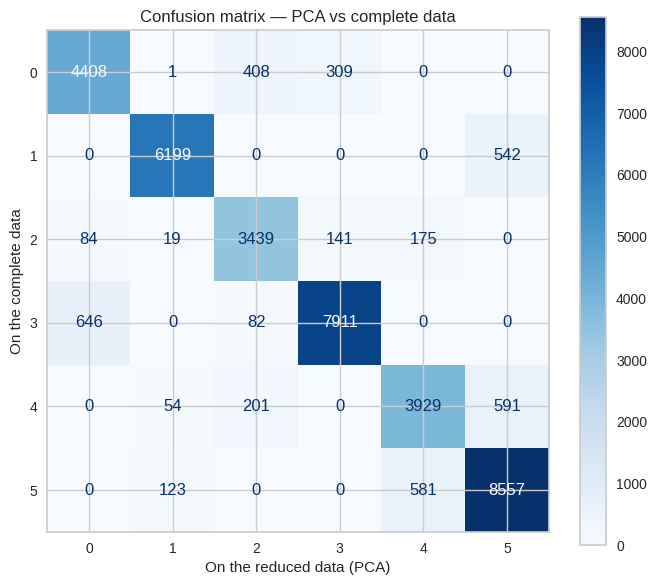

In [47]:
cm, clusters_pca_sorted = matchClasses(clusters_full, clusters_pca)

fig, ax = plt.subplots(figsize=(7, 6))

ConfusionMatrixDisplay(cm).plot(
    ax=ax, colorbar=True, cmap="Blues"
)

ax.set_xlabel("On the reduced data (PCA)")
ax.set_ylabel("On the complete data")
ax.set_title("Confusion matrix — PCA vs complete data")

plt.tight_layout()
plt.show()

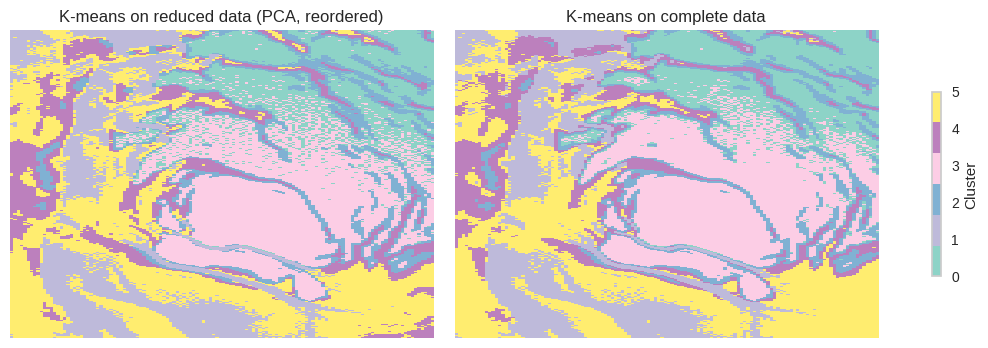

In [48]:
K = 6
cmap = plt.get_cmap("Set3", K)

fig, axes = plt.subplots(1, 2, figsize=(14, 4),
                         gridspec_kw={"wspace": 0.05})

titles = ["K-means on reduced data (PCA, reordered)", "K-means on complete data"]
images = [clusters_pca_sorted, clusters_full]

for ax, img, title in zip(axes, images, titles):
    im = ax.imshow(img.reshape((n_pixel_x, n_pixel_y)),
                   interpolation="nearest", aspect="auto", cmap=cmap)
    ax.set_title(title)
    ax.axis("off")

fig.colorbar(im, ax=axes, ticks=range(K), label="Cluster", shrink=0.6)

plt.show()

**Interpretation**: Now the way the classes are assigned coincides and the coloring between the two images is consistent. 

##### <span style="color:purple">**Todo:** Write a function `diffPlot` to visually compare two classifications.</span>

Write a function that counts the number of points classified differently between two classifications, and displays the image of Mars with these distinct points in black. We will apply it to two classifications whose classes have been previously reordered to match (via the `matchClasses` function for example).

_Remark:_ To create a colormap from a numpy array, we can use the [`colors.ListedColormap`](https://matplotlib.org/stable/api/_as_gen/matplotlib.colors.ListedColormap.html) function of matplotlib.

In [49]:
# %load solutions/kmeans/diffPlot.py
def diffPlot(classif1, classif2):
    """
    Highlight pixels classified differently between two classifications.
    Differing pixels are shown in black.

    Parameters
    ----------
    classif1 : array-like (n_samples,) — reference classification
    classif2 : array-like (n_samples,) — classification to compare
    """
    n = len(classif1)
    K = classif1.max() + 1

    diff_mask = classif1 != classif2
    nb_diff = diff_mask.sum()

    print(f"Differently classified pixels : {nb_diff} / {n} ({nb_diff/n*100:.1f}%)")

    # Build colormap with black for differing pixels
    base_cmap = plt.get_cmap("Set3", K)
    cmap = colors.ListedColormap(
        np.vstack([base_cmap.colors, [0, 0, 0, 1]])
    )

    clusters = classif1.copy()
    clusters[diff_mask] = K + 1

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(clusters.reshape((n_pixel_x, n_pixel_y)),
              interpolation="nearest", aspect="auto", cmap=cmap)
    ax.set_title(f"Differences — {nb_diff/n*100:.1f}% of pixels differ")
    ax.axis("off")

    plt.tight_layout()
    plt.show()

Differently classified pixels : 3957 / 38400 (10.3%)


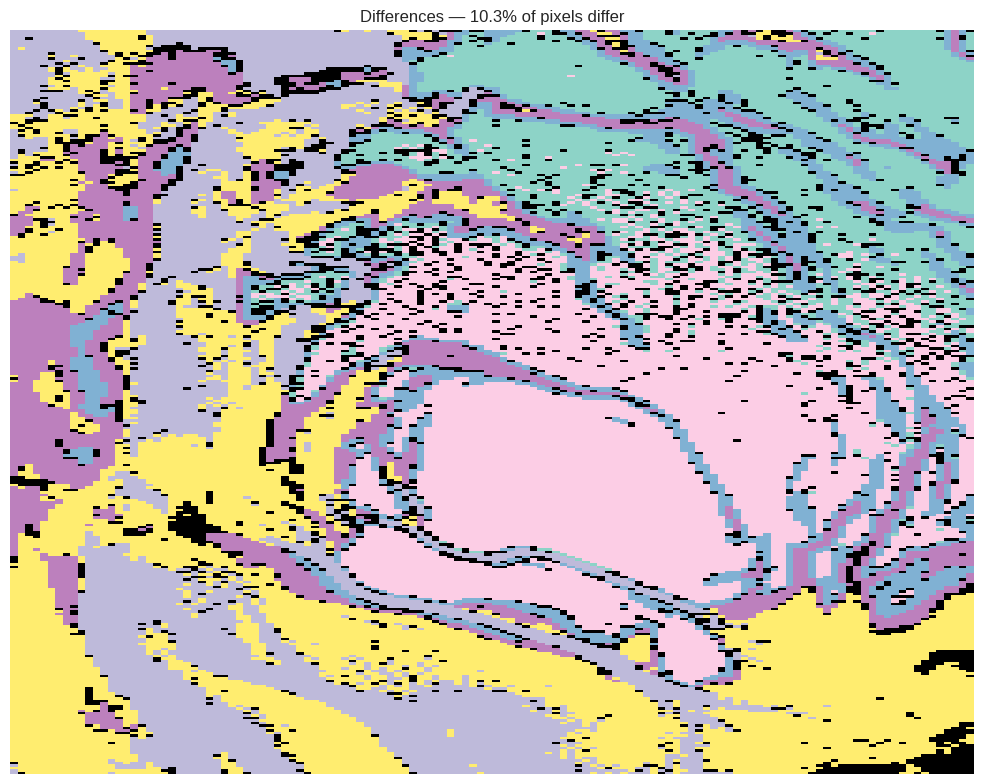

In [50]:
diffPlot(clusters_full, clusters_pca_sorted)

We can also use other scores, such as the mutual information or the Fowlkes-Mallows score.

In [51]:
from sklearn.metrics import normalized_mutual_info_score, fowlkes_mallows_score

In [52]:
similarity_nmi = normalized_mutual_info_score(clusters_full, clusters_pca)
similarity_fm = fowlkes_mallows_score(clusters_full, clusters_pca)

print("Normalized Mutual Information score: %f" % similarity_nmi)
print("Fowlkes Mallows score              : %f" % similarity_fm)

Normalized Mutual Information score: 0.780042
Fowlkes Mallows score              : 0.824958


**Interpretation**: The scores obtained with both external metrics are high, meaning that the classifications obtained are similar with and without PCA.

### Agglomerative Clustering

The $k$-means algorithm leads to satisfactory results. 
We will try to compare it to other classification techniques seen in class. The DBSCAN algorithm is very time consuming and, as its results are not convincing, it has been abandoned. 

In this section, we are interested in the hierarchical ascending classification (CAH). 

In [53]:
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch

#### CAH on a sub-sample

The CAH method is much more time consuming than the $k$-means algorithm. Therefore, we will first focus on a sub-sample to allow easier debugging (if needed!).

In [54]:
mars_reduced_samples = mars_reduced[::10]

print("mars data full sample size:", mars_reduced.shape)
print("mars data sub-sample size :", mars_reduced_samples.shape)

mars data full sample size: (38400, 3)
mars data sub-sample size : (3840, 3)


##### <span style="color:purple">**Todo:** Determine the number of clusters using the elbow method.</span>

Special attention will be paid to the first point. In the first instance, a Ward linkage can be used.

In [55]:
### TO BE COMPLETED ### 

[...]

[Ellipsis]

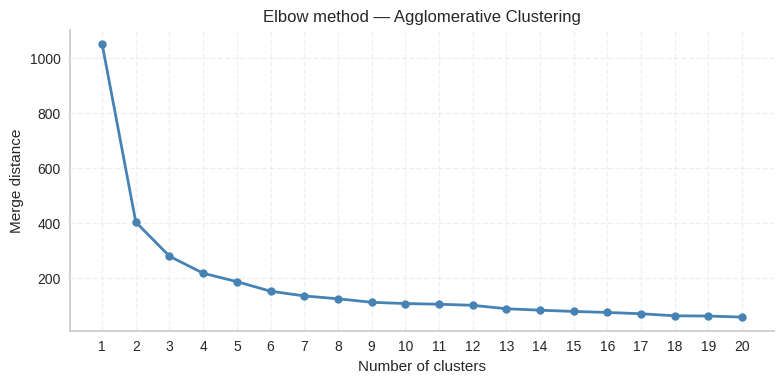

In [56]:
# %load solutions/ac/ac_elbow1.py
K = 6

ac = AgglomerativeClustering(linkage="ward", compute_distances=True)
ac.fit(mars_reduced_samples)

n_sizes = 20
x = np.arange(n_sizes, 0, -1)
y = ac.distances_[-n_sizes:]

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(x, y, marker="o", color="steelblue", linewidth=2, markersize=6)

ax.set_xlabel("Number of clusters")
ax.set_ylabel("Merge distance")
ax.set_title("Elbow method — Agglomerative Clustering")
ax.set_xticks(x)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

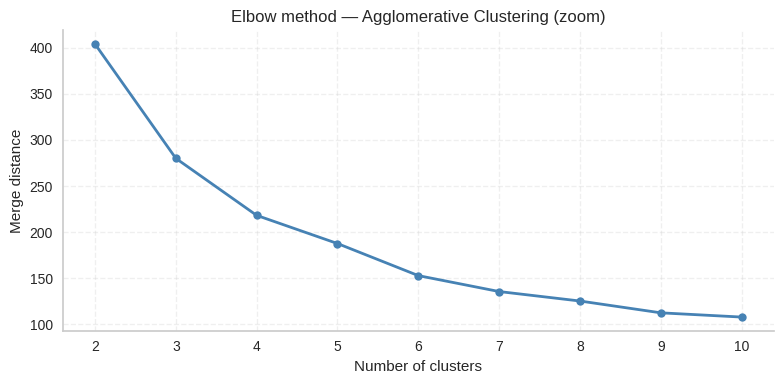

In [57]:
# %load solutions/ac/ac_elbow2.py
n_sizes = 10
x = np.arange(n_sizes, 1, -1)
y = ac.distances_[-n_sizes:-1]

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(x, y, marker="o", color="steelblue", linewidth=2, markersize=6)

ax.set_xlabel("Number of clusters")
ax.set_ylabel("Merge distance")
ax.set_title("Elbow method — Agglomerative Clustering (zoom)")
ax.set_xticks(x)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

We could also have used the vizualizer of the `yellowstone` package.

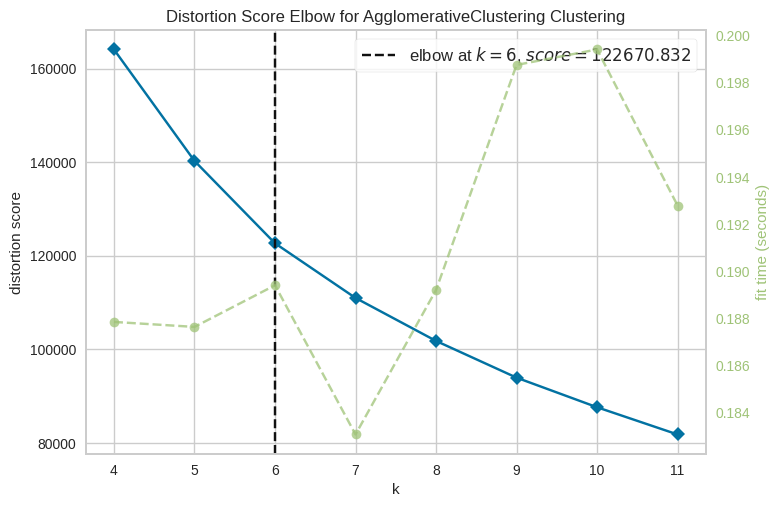

In [58]:
ac = AgglomerativeClustering(linkage='ward', compute_distances=True)
visualizer = KElbowVisualizer(ac, k=(4,12), force_model=True)

visualizer.fit(mars_reduced_samples)  # Fit the data to the visualizer
visualizer.show()   
plt.show()

##### <span style="color:purple">**Todo:** Visualize the dendrogram associated to the reduced data set.</span>

In [59]:
### TO BE COMPLETED ### 

[...]

[Ellipsis]

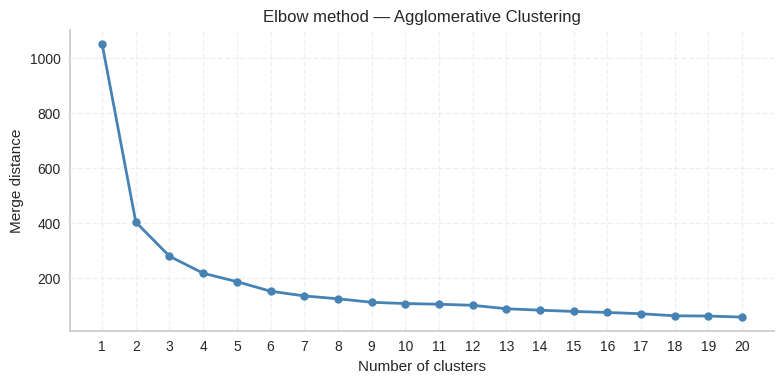

In [60]:
# %load solutions/ac/ac_dendrogram.py
K = 6

ac = AgglomerativeClustering(linkage="ward", compute_distances=True)
ac.fit(mars_reduced_samples)

n_sizes = 20
x = np.arange(n_sizes, 0, -1)
y = ac.distances_[-n_sizes:]

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(x, y, marker="o", color="steelblue", linewidth=2, markersize=6)

ax.set_xlabel("Number of clusters")
ax.set_ylabel("Merge distance")
ax.set_title("Elbow method — Agglomerative Clustering")
ax.set_xticks(x)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

##### <span style="color:purple">**Todo:** Evaluate the effect of the choice of the linkage function.</span>

You may represent the dendrogram for each type of linkage. This can be done by further reducing the size of the dataset.

In [61]:
mars_reduced2_samples = mars_reduced[::100]

print("mars data full sample size:", mars_reduced.shape)
print("mars data sub-sample size :", mars_reduced2_samples.shape)

mars data full sample size: (38400, 3)
mars data sub-sample size : (384, 3)


In [62]:
### TO BE COMPLETED ### 

[...]

[Ellipsis]

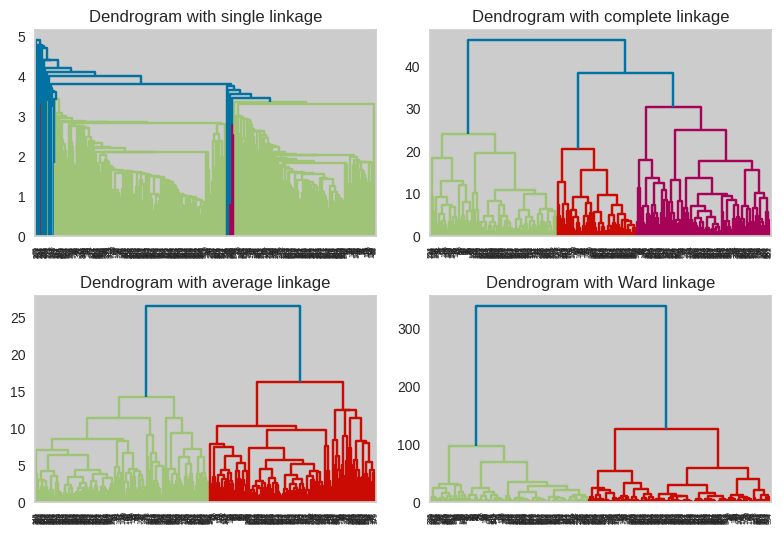

In [63]:
# %load solutions/ac/ac_linkage.py
plt.subplot(2,2,1)
linkage_matrix_single = sch.linkage(mars_reduced2_samples, method='single')
sch.dendrogram(linkage_matrix_single)
plt.title("Dendrogram with single linkage")

plt.subplot(2,2,2)
linkage_matrix_complete = sch.linkage(mars_reduced2_samples, method='complete')
sch.dendrogram(linkage_matrix_complete)
plt.title("Dendrogram with complete linkage")

plt.subplot(2,2,3)
linkage_matrix_average = sch.linkage(mars_reduced2_samples, method='average')
sch.dendrogram(linkage_matrix_average)
plt.title("Dendrogram with average linkage")

plt.subplot(2,2,4)
linkage_matrix_ward = sch.linkage(mars_reduced2_samples, method='ward')
sch.dendrogram(linkage_matrix_ward)
plt.title("Dendrogram with Ward linkage")

plt.tight_layout()
plt.show()

#### Visualize agglomerative clustering

##### <span style="color:purple">**Todo:** Display the reduced data set, colored according to the classes found by CAH.</span>

You may plot the scatterplot composed of the first two components of this reduced data set. You can choose to work either on the subsample defined at the beginning of this section, or on the complete data set.

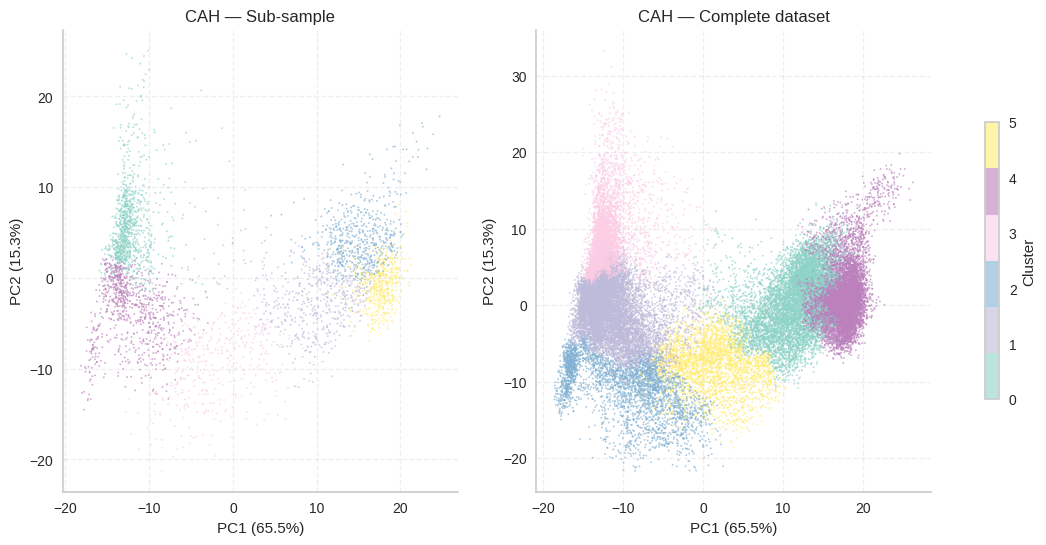

In [64]:
# %load solutions/ac/ac_acp.py
K = 6
cmap = plt.get_cmap("Set3", K)

ac_ss = AgglomerativeClustering(n_clusters=K, compute_distances=True, linkage="ward")
clusters_ac_ss = ac_ss.fit_predict(mars_reduced_samples)

ac = AgglomerativeClustering(n_clusters=K, compute_distances=True, linkage="ward")
clusters_ac = ac.fit_predict(mars_reduced)

# --- #

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

datasets = [(mars_reduced_samples, clusters_ac_ss, "Sub-sample"),
            (mars_reduced,         clusters_ac,    "Complete dataset")]

for ax, (data, clusters, title) in zip(axes, datasets):
    sc = ax.scatter(data[:, 0], data[:, 1],
                    c=clusters, s=1, alpha=0.6, cmap=cmap)
    ax.set_title(f"CAH — {title}")
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(True, linestyle="--", alpha=0.3)

fig.colorbar(sc, ax=axes, ticks=range(K), label="Cluster", shrink=0.6)

plt.show()

**Interpretation**: As before, the classes may not have the same label, hence the color swap.

##### <span style="color:purple">**Todo:** Represent the geological composition of Mars for 6 classes, using the CAH algorithm.</span>

Plot side by side the scatterplot of the first two components of the reduced data set, and the reconstructed image of Mars. Color these two graphs in a consistent manner.

In [65]:
### TO BE COMPLETED ### 

[...]

[Ellipsis]

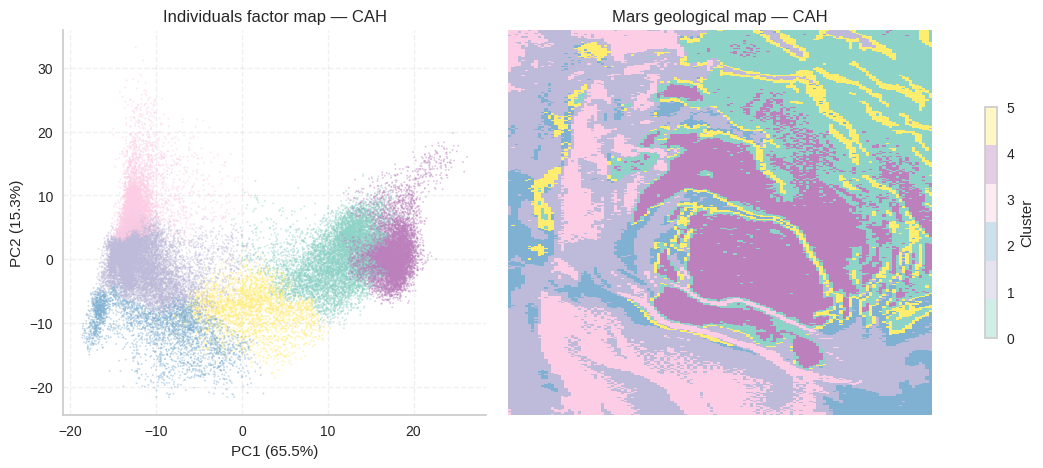

In [66]:
# %load solutions/ac/ac_img.py
K = 6
cmap = plt.get_cmap("Set3", K)

fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                         gridspec_kw={"wspace": 0.05})

# Scatter plot
sc = axes[0].scatter(mars_reduced[:, 0], mars_reduced[:, 1],
                     c=clusters_ac, s=1, alpha=0.4, cmap=cmap)
axes[0].set_title("Individuals factor map — CAH")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].grid(True, linestyle="--", alpha=0.3)

# Mars image
axes[1].imshow(clusters_ac.reshape((n_pixel_x, n_pixel_y)),
               interpolation="nearest", aspect="auto", cmap=cmap)
axes[1].set_title("Mars geological map — CAH")
axes[1].axis("off")

fig.colorbar(sc, ax=axes, ticks=range(K), label="Cluster", shrink=0.6)

plt.show()

## Gaussian Mixture Models

In [ ]:
s

##### <span style="color:purple">**Todo:** Represent the geological composition of Mars for 6 classes, using the GMM algorithm.</span>

Plot side by side the scatterplot of the first two components of the reduced data set, and the reconstructed image of Mars. Color these two graphs in a consistent manner.

In [68]:
### TO BE COMPLETED ### 

[...]

[Ellipsis]

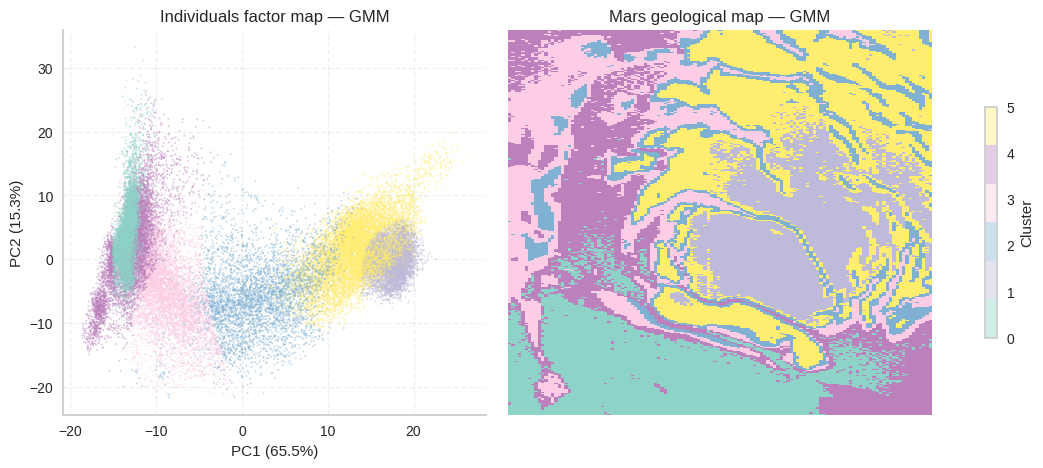

In [69]:
# %load solutions/gmm/gmm_img.py
K = 6
cmap = plt.get_cmap("Set3", K)

gmm = GaussianMixture(n_components=K, n_init=3)
clusters_gmm = gmm.fit_predict(mars_reduced)

# --- #

fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                         gridspec_kw={"wspace": 0.05})

# Scatter plot
sc = axes[0].scatter(mars_reduced[:, 0], mars_reduced[:, 1],
                     c=clusters_gmm, s=1, alpha=0.4, cmap=cmap)
axes[0].set_title("Individuals factor map — GMM")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].grid(True, linestyle="--", alpha=0.3)

# Mars image
axes[1].imshow(clusters_gmm.reshape((n_pixel_x, n_pixel_y)),
               interpolation="nearest", aspect="auto", cmap=cmap)
axes[1].set_title("Mars geological map — GMM")
axes[1].axis("off")

fig.colorbar(sc, ax=axes, ticks=range(K), label="Cluster", shrink=0.6)

plt.show()

##### <span style="color:purple">**Question:** Is the BIC adapted to select the right number of clusters in our problem?</span>

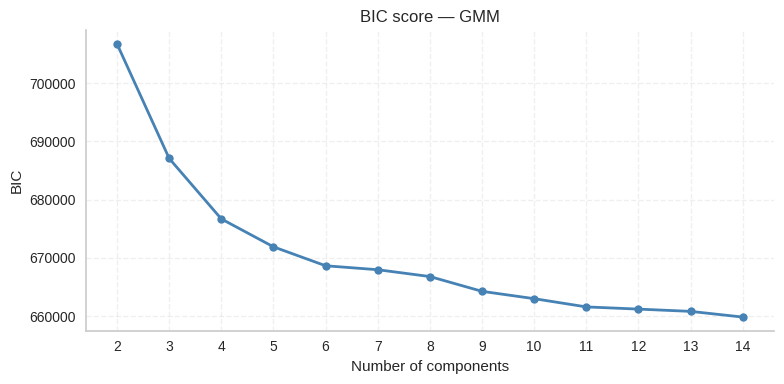

In [70]:
# %load solutions/gmm/gmm_bic.py
k_max = 15

bic = np.array([
    GaussianMixture(n_components=k, init_params="kmeans", n_init=3)
    .fit(mars_reduced).bic(mars_reduced)
    for k in range(2, k_max)
])

# --- #

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(range(2, k_max), bic, marker="o", color="steelblue",
        linewidth=2, markersize=6)
ax.set_xlabel("Number of components")
ax.set_ylabel("BIC")
ax.set_title("BIC score — GMM")
ax.set_xticks(range(2, k_max))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

##### <span style="color:purple">**Todo:** Propose an alternative method.</span>

You can for instance use the silhouette score.

In [71]:
### TO BE COMPLETED ### 

[...]

[Ellipsis]

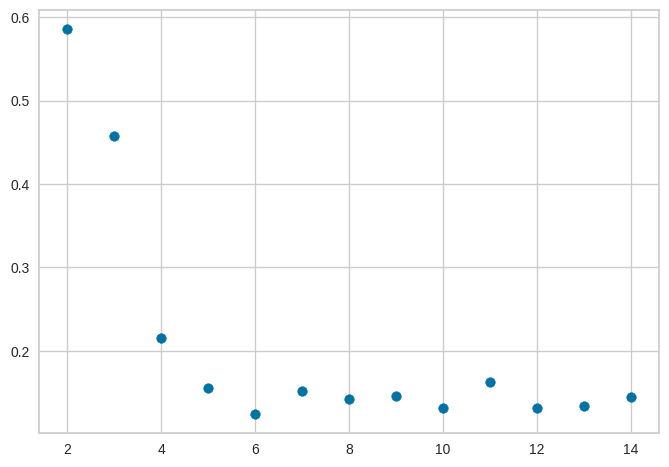

In [97]:
# %load solutions/gmm/gmm_silhouette.py
k_max = 15

silhouette = []
for k in range(2, k_max):
    gmm = GaussianMixture(n_components=k, init_params='kmeans', n_init=3)
    clusters_gmm = gmm.fit_predict(mars_reduced)
    silhouette.append( silhouette_score(mars_reduced, clusters_gmm, metric='euclidean') )
silhouette = np.array(silhouette)

plt.scatter(range(2, k_max), silhouette)
plt.show()

## Comparison of clustering algorithms

The purpose of this last section is to compare the different results we obtained previously.

### Visualize Kmeans versus GMM components

In [73]:
from scipy.spatial.distance import cdist
from matplotlib.patches import Ellipse

##### <span style="color:purple">**Todo:** Write a function `plotKmeans` that draws circles around each of the clusters identified by the kmeans algorithm.</span>

To do this, complete the following function. The circles must be of the same color as the points that make up the corresponding cluster.

In [74]:
# %load solutions/compare/plotKmeans.py
def plotKmeans(kmeans, data, n_clusters=6):
    """
    Plot K-means clustering with circles representing each cluster's extent.

    Parameters
    ----------
    kmeans     : fitted or unfitted KMeans instance
    data       : array-like (n_samples, 2) — data to cluster and display
    n_clusters : int — number of clusters
    """
    kmeans.fit(data)
    clusters_kmeans = kmeans.predict(data)
    centers = kmeans.cluster_centers_

    cmap = plt.get_cmap("Set3", n_clusters)
    ax = plt.gca()

    # Scatter plot
    ax.scatter(data[:, 0], data[:, 1],
               c=clusters_kmeans, s=1, alpha=0.4, cmap=cmap)

    # Circles around each cluster
    radii = [cdist(data[clusters_kmeans == i], [center]).max()
             for i, center in enumerate(centers)]

    for i, (center, radius) in enumerate(zip(centers, radii)):
        ax.add_patch(plt.Circle(center, radius,
                                facecolor=cmap.colors[i], edgecolor=cmap.colors[i],
                                alpha=0.3, linewidth=1.5))

    ax.set_aspect("equal")
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(True, linestyle="--", alpha=0.3)

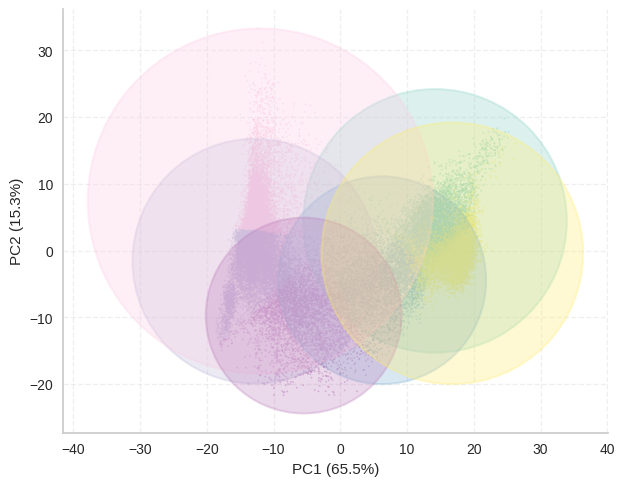

In [75]:
K = 6
kmeans = KMeans(n_clusters=K)

plotKmeans(kmeans, mars_reduced)

The following function allows to plot an ellipse of color `col`, of center `mean` and based on the `covariance` matrix.

In [76]:
def draw_ellipse(mean, covariance, alpha, ax, col="#CCCCCC"):
    """
    Draw a confidence ellipse from a mean vector and covariance matrix.

    Parameters
    ----------
    mean       : array-like (2,) — center of the ellipse
    covariance : array-like (2, 2) — covariance matrix
    alpha      : float — transparency (used as ellipse weight/opacity)
    ax         : matplotlib Axes
    col        : color of the ellipse
    """
    U, s, _ = np.linalg.svd(covariance)
    angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
    width, height = 2 * np.sqrt(s)

    ax.add_patch(Ellipse(mean, 4 * width, 4 * height,
                         angle=angle, alpha=alpha,
                         facecolor=col, edgecolor=col,
                         linewidth=1.5))

##### <span style="color:purple">**Todo:** Write a function `plotGMM` that draws ellipses around each of the clusters identified by the GMM algorithm.</span>

You can freely use the previous function. The ellipses must be of the same color as the points that make up the corresponding cluster, and their opacity (`alpha`) must be related to the weight of the said cluster in the blending model.

In [77]:
# %load solutions/compare/plotGMM.py
def plotGMM(gmm, data, n_clusters=6):
    """
    Plot GMM clustering with ellipses representing each component.
    Ellipse opacity is proportional to the component weight.

    Parameters
    ----------
    gmm        : fitted or unfitted GaussianMixture instance
    data       : array-like (n_samples, 2) — data to cluster and display
    n_clusters : int — number of components
    """
    gmm.fit(data)
    clusters_gmm = gmm.predict(data)

    cmap = plt.get_cmap("Set3", n_clusters)
    ax = plt.gca()

    # Scatter plot
    ax.scatter(data[:, 0], data[:, 1],
               c=clusters_gmm, s=1, alpha=0.4, cmap=cmap)

    # Ellipses around each component
    for i, (mean, cov, weight) in enumerate(zip(gmm.means_,
                                                 gmm.covariances_,
                                                 gmm.weights_)):
        draw_ellipse(mean[:2], cov[:2, :2], weight, ax, cmap.colors[i])

    ax.set_aspect("equal")
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(True, linestyle="--", alpha=0.3)

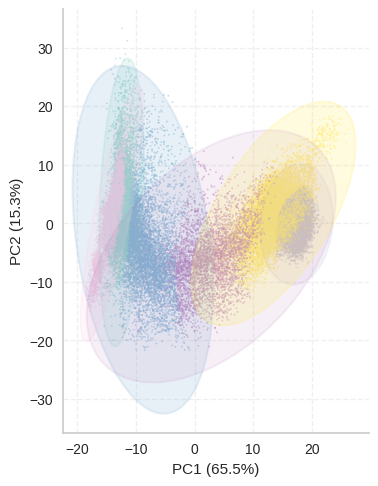

In [78]:
K = 6
gmm = GaussianMixture(n_components=K, init_params='kmeans')

plotGMM(gmm, mars_reduced)

#### Re-indexing of clusters for better visualization

As before, the clusters (moreover found by two different algorithms!) have no chance to match.

In [79]:
K = 6
n_pixel_x = 300
n_pixel_y = 128

kmeans = KMeans(n_clusters=K, n_init=10)
clusters_kmeans = kmeans.fit_predict(mars_reduced)

gmm = GaussianMixture(n_components=K, n_init=10, init_params='kmeans')
clusters_gmm = gmm.fit_predict(mars_reduced)

##### <span style="color:purple">**Todo:** Using a previously defined function, match the classes obtained by kmeans and GMM.</span>

What do you notice?


Classes size: [3706 5116 3176 2902 4082 4182]
Class (in the classif1 numbering): [3 2 5 0 4 1]



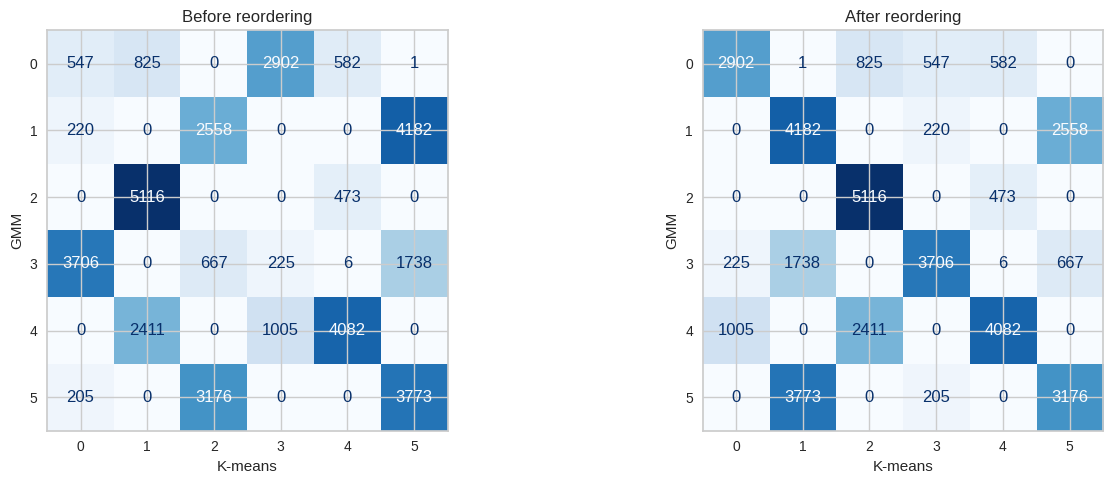

In [80]:
# %load solutions/compare/kmeans_vs_gmm.py
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(confusion_matrix(clusters_gmm, clusters_kmeans)).plot(
    ax=axes[0], colorbar=False, cmap="Blues"
)
axes[0].set_xlabel("K-means")
axes[0].set_ylabel("GMM")
axes[0].set_title("Before reordering")

# --- #

cm, clusters_kmeans_sorted = matchClasses(clusters_gmm, clusters_kmeans)

ConfusionMatrixDisplay(cm).plot(
    ax=axes[1], colorbar=False, cmap="Blues"
)
axes[1].set_xlabel("K-means")
axes[1].set_ylabel("GMM")
axes[1].set_title("After reordering")

plt.tight_layout()
plt.show()

##### <span style="color:purple">**Todo:** Visually compare the kmeans and GMM segmentation. </span>

Visualize side by side the partition obtained by kmeans (re-oroded), the one obtained by GMM and an image highlighting the differently classified pixels.

In [81]:
### TO BE COMPLETED ### 

[...]

[Ellipsis]

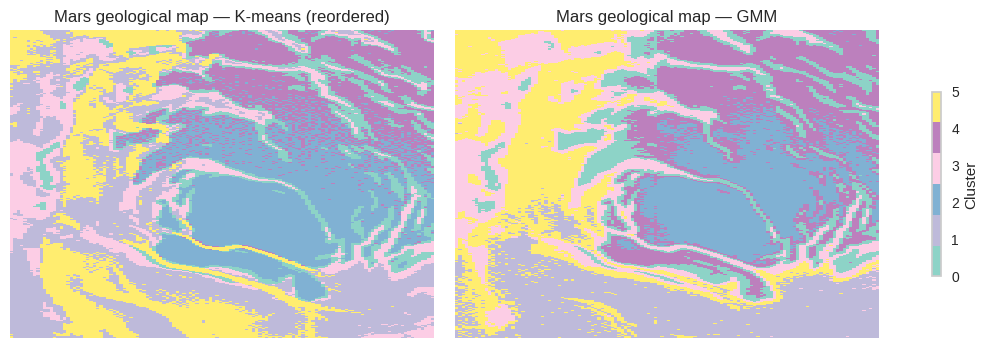

Differently classified pixels : 15236 / 38400 (39.7%)


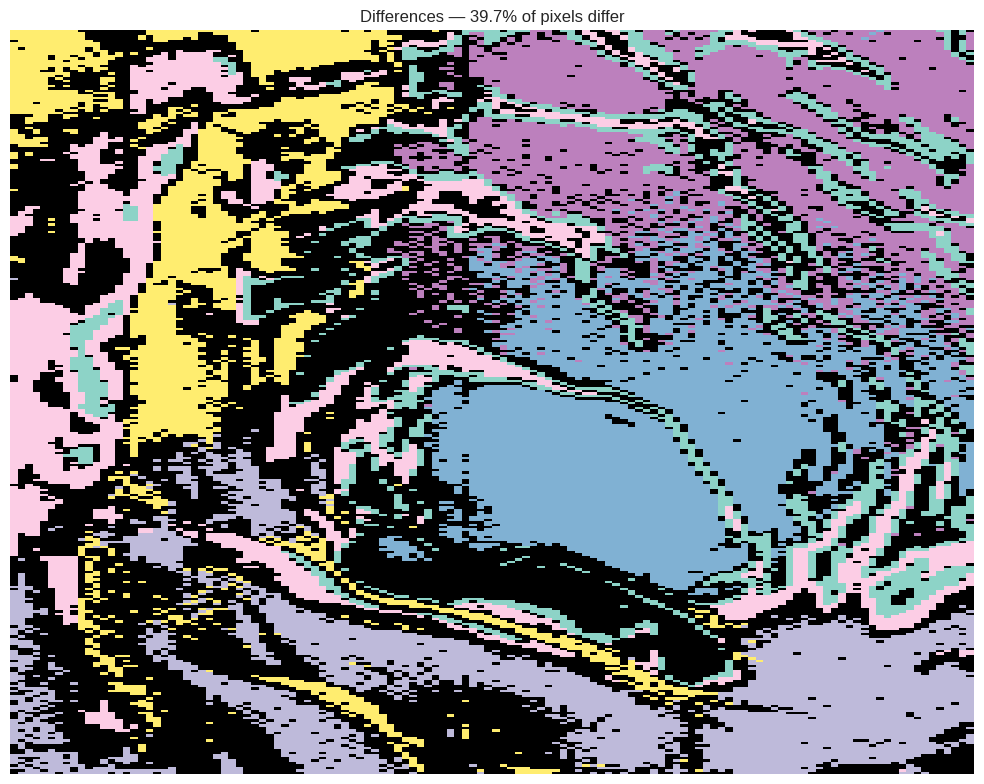

In [82]:
# %load solutions/compare/kmeans_vs_gmm_img.py
K = 6
cmap = plt.get_cmap("Set3", K)

fig, axes = plt.subplots(1, 2, figsize=(14, 4),
                         gridspec_kw={"wspace": 0.05})

titles = ["K-means (reordered)", "GMM"]
images = [clusters_kmeans_sorted, clusters_gmm]

for ax, img, title in zip(axes, images, titles):
    im = ax.imshow(img.reshape((n_pixel_x, n_pixel_y)),
                   interpolation="nearest", aspect="auto", cmap=cmap)
    ax.set_title(f"Mars geological map — {title}")
    ax.axis("off")

fig.colorbar(im, ax=axes, ticks=range(K), label="Cluster", shrink=0.6)

plt.show()

# --- #

diffPlot(clusters_gmm, clusters_kmeans_sorted)

## Comparison to experts ground truth

##### <span style="color:purple">**Todo:** Load the experts ground truth.</span>

Load them as a `numpy`-array of size (38400,)

In [83]:
### TO BE COMPLETED ### 

[...]

[Ellipsis]

In [84]:
# %load solutions/compare/expert_data.py
n_pixel_x = 300
n_pixel_y = 128

clusters_expert = pd.read_csv("data/mask.csv").to_numpy()
clusters_expert = clusters_expert.reshape(n_pixel_x * n_pixel_y)

##### <span style="color:purple">**Question:** Do the ground truth classes seem balanced to you?</span>


In [85]:
### TO BE COMPLETED ### 

[...]

[Ellipsis]

In [86]:
# %load solutions/compare/expert_balance.py
for i in range(10):
    print(i, ':', np.sum(clusters_expert==i) )

0 : 1897
1 : 16611
2 : 2910
3 : 1193
4 : 14704
5 : 95
6 : 983
7 : 7
8 : 0
9 : 0


In [87]:
# %load solutions/compare/expert_merge.py
# Class 7 is far too low to be considered relevant. 
# -> We will treat it as outliers, and merge it with the Class 5. 
# Thus the ground truth consists effectively of 6 classes.

clusters_expert[clusters_expert==7] = 5

for i in range(10):
    print(i, ':', np.sum(clusters_expert==i) )

0 : 1897
1 : 16611
2 : 2910
3 : 1193
4 : 14704
5 : 102
6 : 983
7 : 0
8 : 0
9 : 0


##### <span style="color:purple">**Todo:** View the ground truth obtained by the Mars experts.</span>

In [88]:
### TO BE COMPLETED ### 

[...]

[Ellipsis]

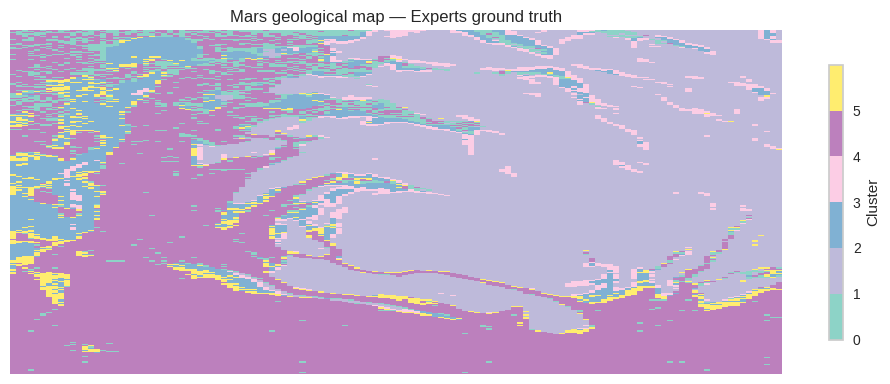

In [89]:
# %load solutions/compare/expert_img.py
K = 6
cmap = plt.get_cmap("Set3", K)

fig, ax = plt.subplots(figsize=(10, 4))

im = ax.imshow(clusters_expert.reshape((n_pixel_x, n_pixel_y)),
               interpolation="nearest", aspect="auto", cmap=cmap)

fig.colorbar(im, ax=ax, ticks=range(K), label="Cluster", shrink=0.8)
ax.set_title("Mars geological map — Experts ground truth")
ax.axis("off")

plt.tight_layout()
plt.show()

##### <span style="color:purple">**Todo:** Visually compare the ground truth to previously obtained classifications.</span>

What do you think about it?

In [90]:
### TO BE COMPLETED ### 

[...]

[Ellipsis]


Classes size: [2356 8346 5738 2761 5098 8280    0]
Class (in the classif1 numbering): [2 1 4 1 1 4 0]



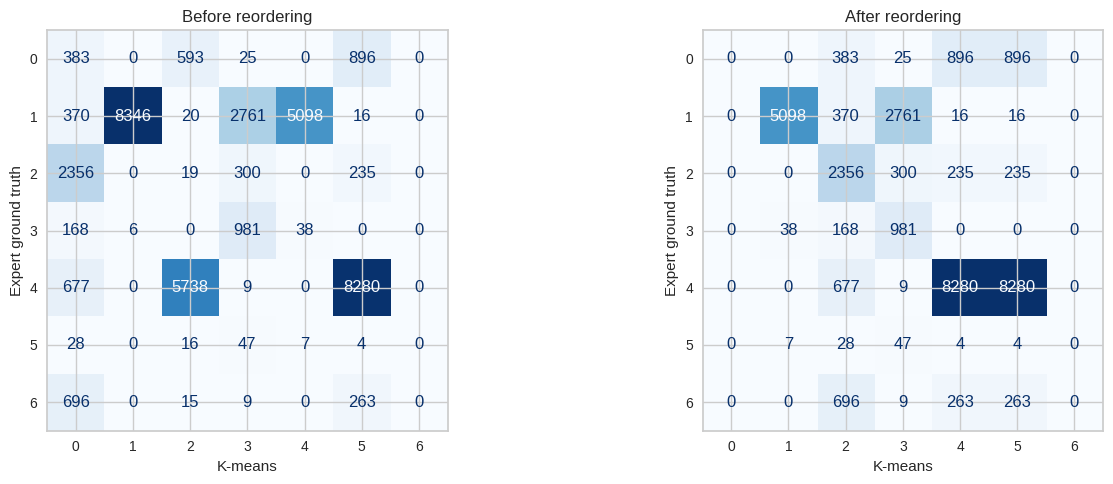

In [91]:
# %load solutions/compare/compare_cm.py
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(confusion_matrix(clusters_expert, clusters_kmeans)).plot(
    ax=axes[0], colorbar=False, cmap="Blues"
)
axes[0].set_xlabel("K-means")
axes[0].set_ylabel("Expert ground truth")
axes[0].set_title("Before reordering")

# --- #

cm, clusters_kmeans_sorted = matchClasses(clusters_expert, clusters_kmeans)

ConfusionMatrixDisplay(cm).plot(
    ax=axes[1], colorbar=False, cmap="Blues"
)
axes[1].set_xlabel("K-means")
axes[1].set_ylabel("Expert ground truth")
axes[1].set_title("After reordering")

plt.tight_layout()
plt.show()


Classes size: [2356 8346 5738 2761 5098 8280    0]
Class (in the classif1 numbering): [2 1 4 1 1 4 0]


Classes size: [3285 6934 5589 2401 7387 6295    0]
Class (in the classif1 numbering): [1 4 1 2 1 4 0]


Classes size: [7788 8115 1356 5369 7441 1178    0]
Class (in the classif1 numbering): [1 4 2 4 1 1 0]



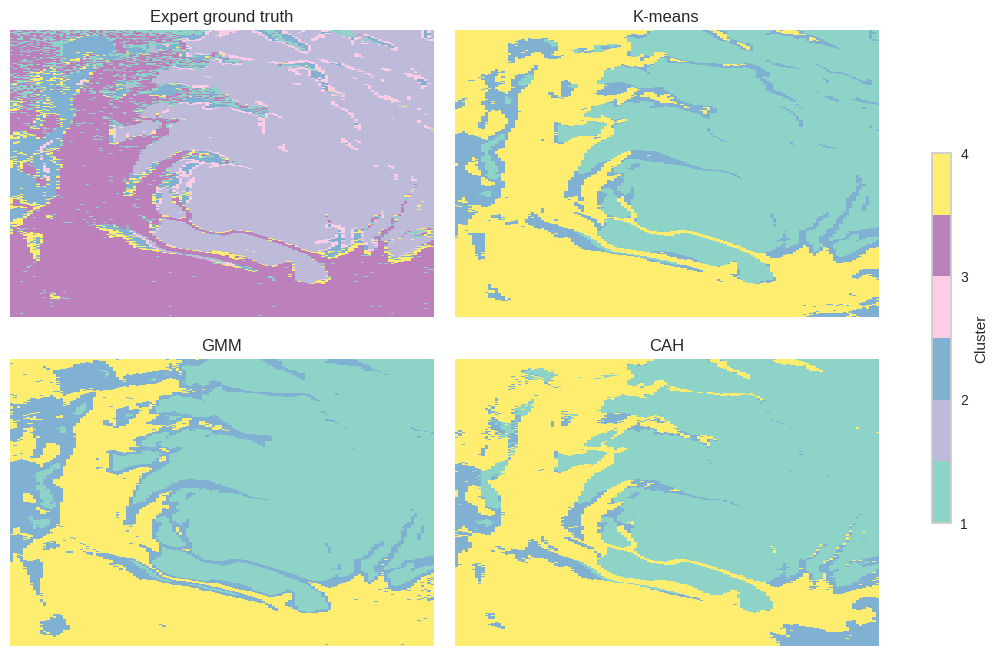

In [92]:
# %load solutions/compare/compare_img.py
K = 6
cmap = plt.get_cmap("Set3", K)
sort = True

# --- #

cm, clusters_kmeans_sorted = matchClasses(clusters_expert, clusters_kmeans)
cm, clusters_gmm_sorted    = matchClasses(clusters_expert, clusters_gmm)
cm, clusters_ac_sorted     = matchClasses(clusters_expert, clusters_ac)

# --- #

titles = ["Expert ground truth", "K-means", "GMM", "CAH"]
images = [
    clusters_expert,
    clusters_kmeans_sorted if sort else clusters_kmeans,
    clusters_gmm_sorted    if sort else clusters_gmm,
    clusters_ac_sorted     if sort else clusters_ac,
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8),
                         gridspec_kw={"wspace": 0.05, "hspace": 0.15})

for ax, img, title in zip(axes.flat, images, titles):
    im = ax.imshow(img.reshape((n_pixel_x, n_pixel_y)),
                   interpolation="nearest", aspect="auto", cmap=cmap)
    ax.set_title(title)
    ax.axis("off")

fig.colorbar(im, ax=axes, ticks=range(K), label="Cluster", shrink=0.6)

plt.show()

**Note:** [Bouveyron (2017)](https://hal.science/hal-01264844) uses the `R` package `HDClassive` to estimate the parameters of Gaussian mixture models in connection with a dimension reduction. The resulting image is still very different from the previous ones. It is difficult to know if an automatic segmentation is more appropriate than another to find what could be a "good" geological map of Mars. This underlines all the difficulties of making informed choices in an unsupervised context.

##### <span style="color:purple">**Todo:** Quantitatively compare the ground truth to previously obtained classifications.</span>

You could use the [Fowlkes-Mallows](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.fowlkes_mallows_score.html) score and the [mutual information](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.normalized_mutual_info_score.html) score for instance.

In [93]:
### TO BE COMPLETED ### 

[...]

[Ellipsis]

In [94]:
# %load solutions/compare/compare_score.py

However, there is some randomness in both versions of the algorithms (Random initialization for $k$-means, random subset of data for agglomerative clustering). To obtain more relevant results, several runs should be conducted and averaged for $k$-means and all the data should be used for agglomerative clustering.

##### <span style="color:purple">**Question:** Does this hazard induce a strong variability in the results?</span>

Perform several runs of the kmeans algorithm and compare the subsequent error scores. 

In [95]:
### TO BE COMPLETED ### 

[...]

[Ellipsis]

In [96]:
# %load solutions/compare/compare_nruns.py